In [5]:
import pandas as pd
df = pd.read_csv('data/istanbulöneri.csv', decimal=',')

In [6]:
df.columns

Index(['Unnamed: 0', 'Neighborhood', 'Furnished', 'Available for Loan',
       'Elevator', 'Household appliances', 'Air conditioning', 'Terrace',
       'Washing Machine', 'Closed Garage', 'Parking Lot', 'Next to sea shore',
       'Hospital', 'Police station', 'Highway', 'Metro', 'Bus stop', 'Sea',
       'sqrt_m2', 'totalrooms', 'buildingage', 'floorloc', 'numberoffloors',
       'bathroom_count', 'has_balcony', 'heating_grouped',
       'district_encoded_x', 'price_per_m2', 'security_features',
       'water_features', 'cephe_yonu', 'toplam_cephe', 'banyo_durumu',
       'havuz_var', 'luxury_pool_score', 'luxury_score', 'konfor_skoru',
       'transport_access', 'social_facility_score', 'Neighborhood_encoded',
       'calculated_total', 'district_encoded', 'Neighborhood_encoded_final',
       'location_score', 'luxury_score_final', 'living_score'],
      dtype='object')

In [7]:
df.describe

<bound method NDFrame.describe of        Unnamed: 0        Neighborhood  Furnished  Available for Loan  \
0               0   5903996.213333337          0                   1   
1               1    9181251.82351508          0                   1   
2               2   4919030.714208871          0                   1   
3               3   10081351.94557823          0                   1   
4               4   15475726.96461545          0                   1   
...           ...                 ...        ...                 ...   
21287       21301   7745735.980941405          1                   1   
21288       21302  11239977.249127308          1                   1   
21289       21303   20270567.25686305          1                   1   
21290       21304   7514497.950061776          1                   0   
21291       21305    5740004.19508052          1                   1   

       Elevator  Household appliances  Air conditioning  Terrace  \
0             0                  

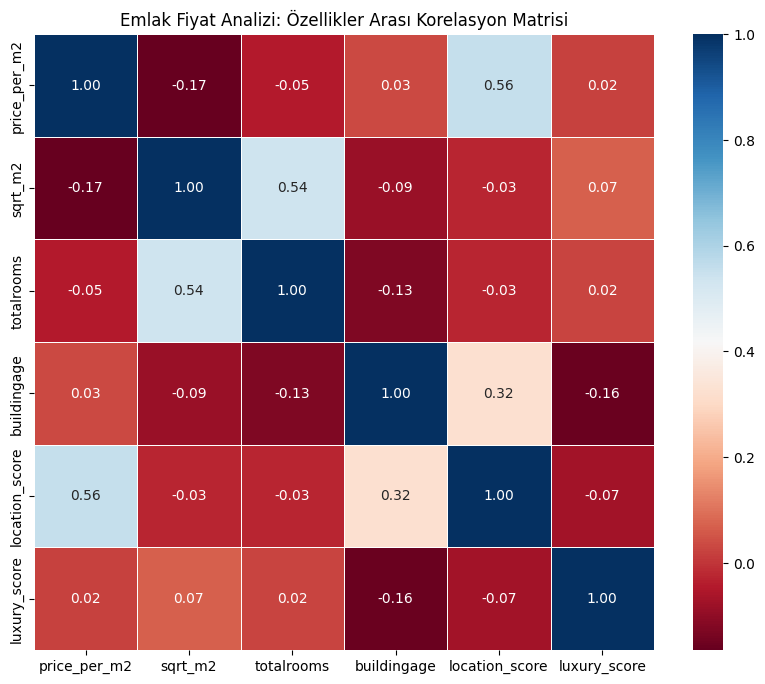

In [16]:
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt

# Analiz için en kritik 6 özellik seçilir
selected_features = [
    'price_per_m2', 'sqrt_m2', 'totalrooms', 
    'buildingage', 'location_score', 'luxury_score'
]

# Korelasyon matrisinin hesaplanması
corr_matrix = df[selected_features].corr()

# Görselleştirme
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)

plt.title("Emlak Fiyat Analizi: Özellikler Arası Korelasyon Matrisi")
plt.show()

In [ ]:
df2 = pd.read_csv('cleanedistanbuldb.csv')

In [ ]:
df.drop(columns=["sea_view_score"],inplace=True)

KeyError: "['sea_view_score'] not found in axis"

In [ ]:
import numpy as np  #bu şekil yaparım ancak şu anlık df de outlier yaptık 21k veri var df2 de 34k veri var 
#aynı index şekline getirmem lazım

df['sea_view_score'] = np.where(
    (df2['Sea'] == 1) | (df2['Next to sea shore'] == 1),
    np.where(
        df2['floorloc'] >= 3,  # Yüksek katlar için premium skor
        2,  # Direkt deniz manzarası
        1   # Uzaktan görünüyor
    ),
    0  # Manzara yok
)

ValueError: Length of values (34843) does not match length of index (21292)

In [ ]:
df2_filtered=df2.loc[df.index]
df2_filtered

,District,Neighborhood,Adrtisement Date,mg,mn,Furnished,Using status,Available for Loan,From who,Swap,...,price,log_price,sqrt_m2,totalrooms,buildingage,floorloc,numberoffloors,bathroom_count,has_balcony,heating_grouped
0,Tuzla,Aydınlı Mh.,04.01.2020,50.0,40.0,Yes,Free,Yes,From owner,No,...,165000.0,12.013707,7.071068,2.0,7.5,5.0,13,1,0.0,natural_gas
1,Fatih,Katip Kasım Mh.,06.01.2020,42.0,42.0,No,Free,Yes,From bank,No,...,207000.0,12.240479,6.480741,2.0,35.0,0.0,30,1,0.0,underfloor
2,Çekmeköy,Çatalmeşe Mh.,31.12.2019,55.0,45.0,No,Property owner,Yes,From owner,Yes,...,153000.0,11.938200,7.416198,2.0,1.0,-1.0,7,1,0.0,natural_gas
3,Çekmeköy,Mehmet Akif Ersoy Mah.,29.12.2019,62.0,46.0,No,Property owner,Yes,From owner,Yes,...,205000.0,12.230770,7.874008,2.0,0.0,1.0,5,1,0.0,natural_gas
4,Küçükçekmece,Halkalı Merkez Mh.,01.01.2020,70.0,55.0,No,Property owner,Yes,From owner,No,...,150000.0,11.918397,8.366600,2.0,7.5,0.5,4,1,0.0,natural_gas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21287,Gaziosmanpaşa,Bağlarbaşı Mh.,03.01.2020,150.0,145.0,No,Free,Yes,From the real estate office,No,...,525000.0,13.171155,12.247449,4.0,13.0,2.0,4,2,1.0,natural_gas
21288,Pendik,Güzelyalı Mh.,03.01.2020,110.0,102.0,No,Free,No,From the real estate office,No,...,225000.0,12.323860,10.488088,4.0,13.0,3.0,6,1,1.0,natural_gas
21289,Fatih,Şehremini Mh.,26.12.2019,125.0,120.0,No,Tenant,Yes,From the real estate office,No,...,700000.0,13.458837,11.180340,4.0,35.0,4.0,4,1,1.0,natural_gas
21290,Bahçelievler,Siyavuşpaşa Mh.,06.01.2020,115.0,100.0,No,Free,Yes,From the real estate office,No,...,340000.0,12.736704,10.723805,4.0,28.0,6.0,6,1,1.0,natural_gas


In [ ]:
# df ile aynı indekse sahip satırları df2'den seç
df2_filtered = df2.loc[df.index]  # df'nin indeksini kullanarak filtrele

# Şimdi sorunsuz atama yapabilirsiniz
df['sea_view_score'] = np.where(
    (df2_filtered['Sea'] == 1) | (df2_filtered['Next to sea shore'] == 1),
    np.where(
        df2_filtered['floorloc'] >= 3,
          2,
          1
    ),
    0
)

In [ ]:
df.price_per_m2

0        28173.913043478264
1          83739.1304347826
2        21428.571428571428
3         35384.61538461538
4         68000.00000000001
                ...        
21287     48666.66666666666
21288     62953.36787564767
21289     83076.92307692309
21290               46000.0
21291               36840.0
Name: price_per_m2, Length: 21292, dtype: object

In [ ]:
df[['sea_view_score', 'price_per_m2']].corr()

,sea_view_score,price_per_m2
sea_view_score,1.00000,-0.00055
price_per_m2,-0.00055,1.00000


In [ ]:
df.drop(columns=["sea_view_score"],inplace=True)

In [ ]:
df.buildingage.unique()

array(['-0.0555555555555555', '1.3333333333333333', '0.0',
       '0.1944444444444444', '1.7222222222222223', '-0.2222222222222222',
       '0.5', '-0.1666666666666666', '1.0555555555555556',
       '0.7777777777777778', '-0.1111111111111111'], dtype=object)

In [ ]:
df[["buildingage","price_per_m2"]].corr()

,buildingage,price_per_m2
buildingage,1.000000,0.030918
price_per_m2,0.030918,1.000000


In [ ]:
df2.buildingage.unique()

array([ 7.5, 35. ,  1. ,  0. ,  3. , 13. ,  4. , 28. ,  2. , 18. , 23. ])

In [ ]:
df2[["buildingage","price"]].corr()

,buildingage,price
buildingage,1.00000,0.06563
price,0.06563,1.00000


In [ ]:
df.drop(columns=["buildingage"],inplace=True)

In [ ]:
df["price_per_m2"]

0        28173.913043478264
1          83739.1304347826
2        21428.571428571428
3         35384.61538461538
4         68000.00000000001
                ...        
21287     48666.66666666666
21288     62953.36787564767
21289     83076.92307692309
21290               46000.0
21291               36840.0
Name: price_per_m2, Length: 21292, dtype: object

In [ ]:
df2.mn

0         40.0
1         42.0
2         45.0
3         46.0
4         55.0
         ...  
34838    185.0
34839    250.0
34840    310.0
34841    121.0
34842    111.0
Name: mn, Length: 34843, dtype: float64

In [ ]:
df.columns

Index(['Unnamed: 0', 'Neighborhood', 'Furnished', 'Available for Loan',
       'Elevator', 'Household appliances', 'Air conditioning', 'Terrace',
       'Washing Machine', 'Closed Garage', 'Parking Lot', 'Next to sea shore',
       'Hospital', 'Police station', 'Highway', 'Metro', 'Bus stop', 'Sea',
       'sqrt_m2', 'totalrooms', 'floorloc', 'numberoffloors', 'bathroom_count',
       'has_balcony', 'heating_grouped', 'district_encoded_x', 'price_per_m2',
       'security_features', 'water_features', 'cephe_yonu', 'toplam_cephe',
       'banyo_durumu', 'havuz_var', 'luxury_pool_score', 'luxury_score',
       'konfor_skoru', 'transport_access', 'social_facility_score',
       'Neighborhood_encoded', 'calculated_total', 'district_encoded',
       'Neighborhood_encoded_final', 'location_score', 'luxury_score_final',
       'living_score'],
      dtype='object')

In [ ]:
print(df["price_per_m2"].dtype)  # float64 veya int64 olmalı
print(df2["mn"].dtype)          # float64 veya int64 olmalı

object
float64


In [ ]:
df.dtypes[df.dtypes=="object"]

Neighborhood                  object
sqrt_m2                       object
totalrooms                    object
floorloc                      object
numberoffloors                object
has_balcony                   object
heating_grouped               object
district_encoded_x            object
price_per_m2                  object
cephe_yonu                    object
toplam_cephe                  object
banyo_durumu                  object
luxury_score                  object
konfor_skoru                  object
transport_access              object
social_facility_score         object
Neighborhood_encoded          object
calculated_total              object
district_encoded              object
Neighborhood_encoded_final    object
location_score                object
luxury_score_final            object
living_score                  object
dtype: object

In [ ]:
total=0
for i in df.Neighborhood:  
    if isinstance(i,str):
        i+=1 #i bir string olduğunda i += 1 işlemi geçersizdir (string + integer hatası).
        total=total + i #total değişkenine string eklemeye çalışıyorsunuz
print(total)

TypeError: can only concatenate str (not "int") to str

In [ ]:
countstr=sum(isinstance(i,str) for i in df.Neighborhood)
countstr

21292

In [ ]:
neighborhood_counts = df['Neighborhood'].value_counts()
neighborhood_counts

Neighborhood
7510377.975376197     486
7368709.090909091     444
10081351.94557823     408
11239977.249127308    384
7958992.506203474     325
                     ... 
17543567.745050583      1
15821653.584864443      1
86770737.46002468       1
19107981.20114439       1
12692501.01831634       1
Name: count, Length: 516, dtype: int64

In [ ]:
# Sayısal dönüşüm denemesi (başarısız olanlar NaN olacak)
df['Neighborhood_Numeric'] = pd.to_numeric(df['Neighborhood'], errors='coerce')

# Dönüşüm başarı oranı
conversion_rate = df['Neighborhood_Numeric'].notna().mean()
print(f"Başarıyla dönüştürülen oran: {conversion_rate:.2%}")

Başarıyla dönüştürülen oran: 100.00%


In [ ]:
frequency_table = df['Neighborhood_Numeric'].value_counts().reset_index()
frequency_table.columns = ['Neighborhood_Value', 'Count']
print(frequency_table.tail(500))

     Neighborhood_Value  Count
16         1.161623e+07    196
17         1.086814e+07    193
18         6.572781e+06    188
19         1.011091e+07    183
20         6.592332e+06    181
..                  ...    ...
511        1.754357e+07      1
512        1.582165e+07      1
513        8.677074e+07      1
514        1.910798e+07      1
515        1.269250e+07      1

[500 rows x 2 columns]


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(size=(10,12))
for i,col in df.columns:
    ax=plt.subplot(1,len(3))

<Axes: xlabel='Count', ylabel='Neighborhood_Value'>

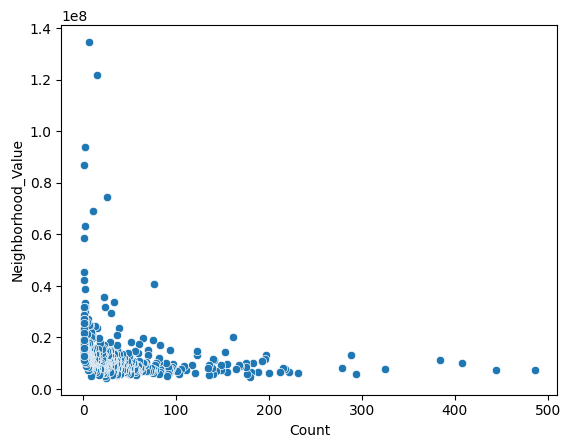

In [ ]:
import seaborn as sns
sns.scatterplot(x="Count",y="Neighborhood_Value",data=frequency_table)

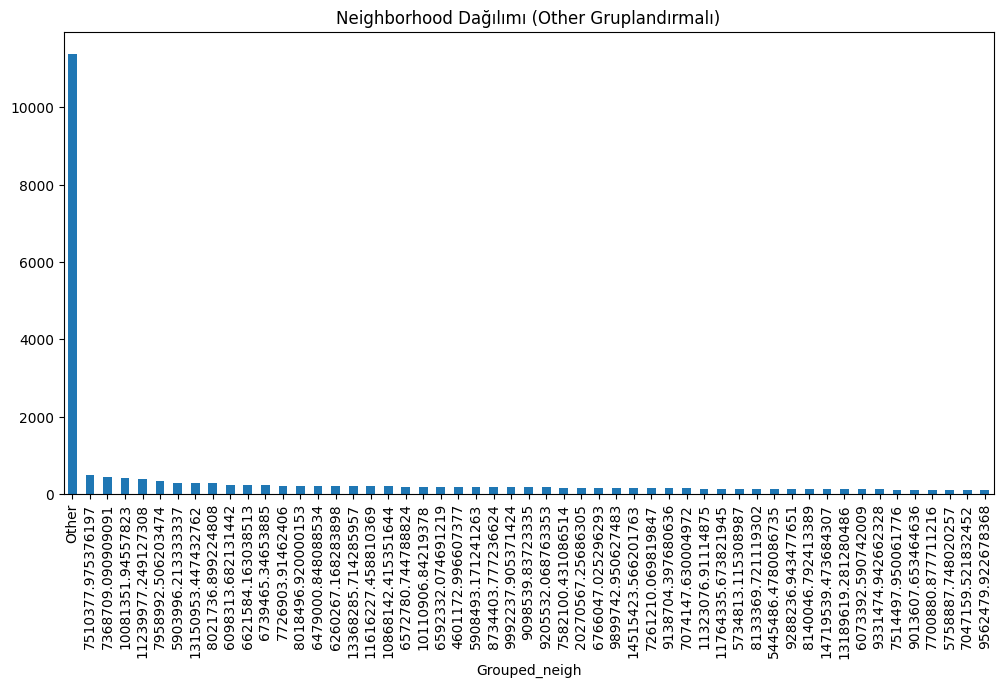

In [ ]:
import matplotlib.pyplot as plt

# Gruplanmış verinin dağılımı
df['Grouped_neigh'].value_counts().plot(kind='bar', figsize=(12,6))
plt.title('Neighborhood Dağılımı (Other Gruplandırmalı)')
plt.show()

In [ ]:
threshold=neighborhood_counts.quantile(0.9)# En sık görülen %5'i koru, diğerlerini "other" yap
top_neighborhoods=neighborhood_counts[neighborhood_counts >= threshold].index
df["Grouped_neigh"]=df["Neighborhood"].where(df["Neighborhood"].isin(top_neighborhoods),"Other")
df["Grouped_neigh"].value_counts()

Grouped_neigh
Other                 11382
7510377.975376197       486
7368709.090909091       444
10081351.94557823       408
11239977.249127308      384
7958992.506203474       325
5903996.213333337       294
13150953.447432762      288
8021736.899224808       279
6098313.682131442       231
6621584.163038513       222
6739465.34653885        222
7726903.91462406        217
8018496.920000153       215
6479000.848088534       212
6260267.168283898       200
13368285.714285957      197
11616227.458810369      196
10868142.415351644      193
6572780.744788824       188
10110906.84219378       183
6592332.074691219       181
4601172.996607377       180
5908493.171241263       176
8734403.777236624       175
9992237.905371424       175
9098539.83723335        169
9205532.068763353       168
7582100.431086514       165
20270567.25686305       161
6766047.025296293       155
9899742.950627483       155
14515423.566201763      153
7261210.069819847       148
9138704.397680636       148
707414

"Other" çok dominantsa (>%30)	Alt gruplar oluşturun (3A veya 3B)

3. Gerekirse Smoothed Mean Encoding (Önerilen)
Aşırı uyumu önlemek için ortalama + global ortalama kombinasyonu:


global_mean = df['price'].mean()
alpha = 5  # Dengeleme faktörü (ne kadar büyükse global ortalama ağır basar)

# Smoothed mean hesapla
smoothed_map = {}
for category in target_map:
    category_mean = target_map[category]
    category_size = df[df['Grouped_neigh_v2'] == category].shape[0]
    smoothed_map[category] = (category_mean * category_size + global_mean * alpha) / (category_size + alpha)

df['Neighborhood_SmoothedEncoded'] = df['Grouped_neigh_v2'].map(smoothed_map)

Grouped_neigh_v2	price	MeanEncoded	SmoothedEncoded
7510377.975376197	4,500,000	4,500,000	4,250,000
Other_Mid	3,200,000	3,200,000	3,100,000

In [ ]:
# "Other" içindeki değerlerin dağılımını inceleyin
other_values = df[df['Grouped_neigh'] == 'Other']['Neighborhood'].value_counts()
print(other_values.head(20))  # En sık görülen 20 "Other" değeri

Neighborhood
8382087.101021807     96
7885169.661784279     95
15073341.610269276    94
6924789.163434303     94
6086169.861431038     93
7745735.980941405     93
7888589.579044186     92
6260901.088088414     92
8553710.477877008     91
5740004.19508052      91
5220453.548048894     90
9908256.6293101       89
7232062.170071155     84
17175983.865943372    83
6689672.225772072     83
7781863.789934876     83
5968890.652818331     82
11923571.547585225    82
10608073.487428373    82
10020263.12769124     78
Name: count, dtype: int64


In [ ]:
# "Other" olanları sayısal değere çevirip grupla
df['Neighborhood_Numeric'] = pd.to_numeric(df['Neighborhood'], errors='coerce')
df['Grouped_neigh_v2'] = np.where(
    df['Grouped_neigh'] != 'Other',
    df['Grouped_neigh'],
    pd.cut(df['Neighborhood_Numeric'], 
           bins=[0, 5e6, 1e7, np.inf],
           labels=['Other_Low', 'Other_Mid', 'Other_High'])
)

In [ ]:
df["Grouped_neigh_v2"].value_counts()

Grouped_neigh_v2
Other_Mid             6739
Other_High            4609
7510377.975376197      486
7368709.090909091      444
10081351.94557823      408
11239977.249127308     384
7958992.506203474      325
5903996.213333337      294
13150953.447432762     288
8021736.899224808      279
6098313.682131442      231
6739465.34653885       222
6621584.163038513      222
7726903.91462406       217
8018496.920000153      215
6479000.848088534      212
6260267.168283898      200
13368285.714285957     197
11616227.458810369     196
10868142.415351644     193
6572780.744788824      188
10110906.84219378      183
6592332.074691219      181
4601172.996607377      180
5908493.171241263      176
9992237.905371424      175
8734403.777236624      175
9098539.83723335       169
9205532.068763353      168
7582100.431086514      165
20270567.25686305      161
6766047.025296293      155
9899742.950627483      155
14515423.566201763     153
9138704.397680636      148
7261210.069819847      148
7074147.630

In [ ]:
# price_per_m2 ve mn sütunlarını sayısal yapın
df['price_per_m2'] = pd.to_numeric(df['price_per_m2'], errors='coerce')
df2['mn'] = pd.to_numeric(df2['mn'], errors='coerce')

# Eksik değerleri kontrol edin
print(f"price_per_m2'de eksik değerler: {df['price_per_m2'].isna().sum()}")
print(f"mn'de eksik değerler: {df2['mn'].isna().sum()}")

price_per_m2'de eksik değerler: 0
mn'de eksik değerler: 0


In [ ]:
df["price"] = df["price_per_m2"] * df2["mn"]
other_mean = df[df['Grouped_neigh'] == 'Other']['price'].mean()
other_mean

np.float64(5991856.801477385)

In [ ]:
df["Grouped_neigh_v2"].value_counts()

Grouped_neigh_v2
Other_Mid             6739
Other_High            4609
7510377.975376197      486
7368709.090909091      444
10081351.94557823      408
11239977.249127308     384
7958992.506203474      325
5903996.213333337      294
13150953.447432762     288
8021736.899224808      279
6098313.682131442      231
6739465.34653885       222
6621584.163038513      222
7726903.91462406       217
8018496.920000153      215
6479000.848088534      212
6260267.168283898      200
13368285.714285957     197
11616227.458810369     196
10868142.415351644     193
6572780.744788824      188
10110906.84219378      183
6592332.074691219      181
4601172.996607377      180
5908493.171241263      176
9992237.905371424      175
8734403.777236624      175
9098539.83723335       169
9205532.068763353      168
7582100.431086514      165
20270567.25686305      161
6766047.025296293      155
9899742.950627483      155
14515423.566201763     153
9138704.397680636      148
7261210.069819847      148
7074147.630

In [ ]:
target_map = df.groupby('Grouped_neigh_v2')['price'].mean().to_dict()
print("Kategori Ortalamaları:")
print(target_map)

Kategori Ortalamaları:
{'10081351.94557823': 5995981.929998819, '10110906.84219378': 6735568.113872019, '10868142.415351644': 6369653.141977342, '11239977.249127308': 6297254.102516287, '11323076.91114875': 5726336.732262288, '11616227.458810369': 8169800.288833879, '11764335.673821945': 5581899.186419885, '13150953.447432762': 4907691.836873069, '13189619.281280486': 6688671.169973621, '13368285.714285957': 6287547.783334785, '14515423.566201763': 7472000.41744769, '14719539.473684307': 4857672.240592859, '20270567.25686305': 6788216.792683132, '4601172.996607377': 2299305.551981362, '5445486.4780086735': 3906836.1328976746, '5734813.115308987': 5310286.769926226, '5758887.748020257': 5204643.4249330815, '5903996.213333337': 4708233.73537217, '5908493.171241263': 4871823.675686063, '6073392.590742009': 3745529.0191840646, '6098313.682131442': 4907477.985507284, '6260267.168283898': 4859867.219445325, '6479000.848088534': 5173713.626038336, '6572780.744788824': 4675437.091898256, '6592

In [ ]:
countstr=sum(isinstance(i,str) for i in df.Grouped_neigh_v2)
countstr

21292

In [ ]:
# Other_Mid, Other_High, Other_Low gruplarının ortalamalarını hesapla
other_mid_mean = df[df['Grouped_neigh_v2'] == 'Other_Mid']['price'].mean()
other_high_mean = df[df['Grouped_neigh_v2'] == 'Other_High']['price'].mean()
other_low_mean = df[df['Grouped_neigh_v2'] == 'Other_Low']['price'].mean()

print(f"Other_Mid Ortalama: {other_mid_mean:.2f}")
print(f"Other_High Ortalama: {other_high_mean:.2f}")
print(f"Other_Low Ortalama: {other_low_mean:.2f}")

Other_Mid Ortalama: 5614455.33
Other_High Ortalama: 6566636.13
Other_Low Ortalama: 2878637.98


In [ ]:
# Boş bir sütun oluştur
df['Neighborhood_Encoded'] = np.nan

# Other gruplarına ortalama fiyatları ata
df.loc[df['Grouped_neigh_v2'] == 'Other_Mid', 'Neighborhood_Encoded'] = other_mid_mean
df.loc[df['Grouped_neigh_v2'] == 'Other_High', 'Neighborhood_Encoded'] = other_high_mean
df.loc[df['Grouped_neigh_v2'] == 'Other_Low', 'Neighborhood_Encoded'] = other_low_mean

# Diğer değerleri sayısala çevir (hatalı olanlar NaN kalacak)
numeric_values = pd.to_numeric(df['Grouped_neigh_v2'], errors='coerce')
df.loc[~df['Grouped_neigh_v2'].str.startswith('Other'), 'Neighborhood_Encoded'] = numeric_values

In [ ]:
print("Örnek değerler:")
print(df[['Grouped_neigh_v2', 'Neighborhood_Encoded']].sample(10))

print("\nDeğer dağılımı:")
print(df['Neighborhood_Encoded'].describe())

Örnek değerler:
        Grouped_neigh_v2  Neighborhood_Encoded
6122           Other_Mid          5.614455e+06
18553         Other_High          6.566636e+06
9034   9288236.943477651          9.288237e+06
15865  6098313.682131442          6.098314e+06
12203         Other_High          6.566636e+06
19299         Other_High          6.566636e+06
21002  5908493.171241263          5.908493e+06
16843  9205532.068763353          9.205532e+06
5046   7510377.975376197          7.510378e+06
3391           Other_Mid          5.614455e+06

Değer dağılımı:
count    2.129200e+04
mean     7.277235e+06
std      2.360692e+06
min      2.878638e+06
25%      5.614455e+06
50%      6.566636e+06
75%      7.726904e+06
max      2.027057e+07
Name: Neighborhood_Encoded, dtype: float64


Eğer Modeliniz Hızlı ve Basit Olsun İstiyorsanız:
✅ Doğrudan Neighborhood_Encoded Kullanın (Şu anki haliyle)

python
features = ['Neighborhood_Encoded', 'sqrt_m2', 'totalrooms']  # Diğer özelliklerle birlikte
Avantajlar:

Hızlı uygulanabilir

Tree-based modeller (Random Forest, XGBoost) için uygun

Other gruplarının fiyat ilişkisini korur

2. Eğer Lineer Bir Model (Regresyon vb.) Kullanıyorsanız:
✅ Ölçeklendirme + Log Dönüşümü

python
from sklearn.preprocessing import StandardScaler
df['Neighborhood_Scaled'] = StandardScaler().fit_transform(df[['Neighborhood_Encoded']])
# Veya
df['Neighborhood_Log'] = np.log1p(df['Neighborhood_Encoded'])
Neden?

Lineer modeller ölçeklenmiş veri ister

Log dönüşümü sağa çarpıklığı (2.36M std) azaltır

In [ ]:
from sklearn.preprocessing import StandardScaler
df['Neighborhood_Scaled'] = StandardScaler().fit_transform(df[['Neighborhood_Encoded']])

In [ ]:
df.dtypes[df.dtypes=="object"]

Neighborhood                  object
sqrt_m2                       object
totalrooms                    object
floorloc                      object
numberoffloors                object
has_balcony                   object
heating_grouped               object
district_encoded_x            object
cephe_yonu                    object
toplam_cephe                  object
banyo_durumu                  object
luxury_score                  object
konfor_skoru                  object
transport_access              object
social_facility_score         object
Neighborhood_encoded          object
calculated_total              object
district_encoded              object
Neighborhood_encoded_final    object
location_score                object
luxury_score_final            object
living_score                  object
Grouped_neigh                 object
Grouped_neigh_v2              object
dtype: object

In [ ]:
df.columns

Index(['Unnamed: 0', 'Neighborhood', 'Furnished', 'Available for Loan',
       'Elevator', 'Household appliances', 'Air conditioning', 'Terrace',
       'Washing Machine', 'Closed Garage', 'Parking Lot', 'Next to sea shore',
       'Hospital', 'Police station', 'Highway', 'Metro', 'Bus stop', 'Sea',
       'sqrt_m2', 'totalrooms', 'floorloc', 'numberoffloors', 'bathroom_count',
       'has_balcony', 'heating_grouped', 'district_encoded_x', 'price_per_m2',
       'security_features', 'water_features', 'cephe_yonu', 'toplam_cephe',
       'banyo_durumu', 'havuz_var', 'luxury_pool_score', 'luxury_score',
       'konfor_skoru', 'transport_access', 'social_facility_score',
       'Neighborhood_encoded', 'calculated_total', 'district_encoded',
       'Neighborhood_encoded_final', 'location_score', 'luxury_score_final',
       'living_score', 'Neighborhood_Numeric', 'Grouped_neigh',
       'Grouped_neigh_v2', 'price', 'Neighborhood_Encoded',
       'Neighborhood_Scaled'],
      dtype='object'

calculated_total	Hedef değişkenle doğrudan ilişkili olabilir (data leakage)	Kullanmayın

In [ ]:
df["price_per_m2"] = pd.to_numeric(df["price_per_m2"], errors="coerce")

In [ ]:
df["price_mn"] = df["price_per_m2"] * df2["mn"]
df["price_mn"]

0        1.126957e+06
1        3.517043e+06
2        9.642857e+05
3        1.627692e+06
4        3.740000e+06
             ...     
21287    7.056667e+06
21288    6.421244e+06
21289    9.969231e+06
21290    4.600000e+06
21291    2.947200e+06
Name: price_mn, Length: 21292, dtype: float64

In [ ]:
corr_matrix = df.corr(numeric_only=True)  # Sadece sayısal sütunlar için
price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr)

price                   1.000000
price_per_m2            0.574327
Neighborhood_Numeric    0.131088
Hospital                0.124982
Metro                   0.120146
security_features       0.116807
Closed Garage           0.115459
Bus stop                0.113057
Air conditioning        0.109427
water_features          0.097836
Elevator                0.096775
Police station          0.091667
Highway                 0.087482
Neighborhood_Encoded    0.078436
Neighborhood_Scaled     0.078436
Available for Loan      0.073552
luxury_pool_score       0.069309
havuz_var               0.064780
Parking Lot             0.061273
Sea                     0.058780
Household appliances    0.047744
Unnamed: 0              0.046054
bathroom_count          0.024364
Next to sea shore       0.011778
Terrace                 0.008726
Washing Machine         0.007864
Furnished               0.006915
Name: price, dtype: float64


Çok Yüksek Korelasyon (>0.9)
Sorun: Multicollinearity (özelliklerin birbirini tekrarlaması).

Çözüm:

Sadece birini seçin (örneğin, sqrt_m2 ve totalrooms yüksek korelasyonluysa, sqrt_m2'yi tutun).

VIF (Variance Inflation Factor) ile doğrulama yapın:



In [ ]:
features = [
    # Fiziksel
    'sqrt_m2', 'totalrooms', 'bathroom_count', 'floorloc', 
    'numberoffloors', 'has_balcony', 'heating_grouped',
    
    # Lokasyon
    'district_encoded', 'Neighborhood_encoded', 'location_score',
    'Next to sea shore', 'Sea', 'transport_access',
    
    # Lüks/Konfor
    'Furnished', 'Elevator', 'Air conditioning', 'Terrace',
    'Closed Garage', 'luxury_score', 'luxury_pool_score',
    
    # Binary
    'Household appliances', 'Washing Machine', 'Hospital', 'Metro'
]

X = df[features]
y = df['price_mn']  # Hedef değişken

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
X_numeric = X.select_dtypes(include=['int64', 'float64'])

In [ ]:
import pandas as pd
import numpy as np

# Sayısal olması gereken sütunların listesi
numeric_cols = [
    'sqrt_m2', 'totalrooms', 'floorloc', 'numberoffloors',
    'luxury_score', 'konfor_skoru', 'transport_access',
    'social_facility_score', 'location_score', 'living_score'
]

# Dönüşüm (hatalı değerler NaN olacak)
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [ ]:
df['enhanced_location_score'] = (
    0.6 * df['location_score'] + 
    0.3 * df['transport_access'] + 
    0.1 * df['social_facility_score']
)

In [ ]:
df['luxury_composite'] = (
    0.7 * df['luxury_score'] +
    0.2 * df['Air conditioning'] +
    0.1 * df['Closed Garage']
)

In [ ]:
df['location_x_luxury'] = df['enhanced_location_score'] * df['luxury_composite']

In [ ]:
df = df[df['price'] < df['price'].quantile(0.99)]

In [ ]:
corr_matrix = df.corr(numeric_only=True)  # Sadece sayısal sütunlar için
price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr)

price                      1.000000
price_per_m2               0.574327
location_score             0.318526
enhanced_location_score    0.170139
living_score               0.146770
transport_access           0.134080
Neighborhood_Numeric       0.131088
konfor_skoru               0.130394
Hospital                   0.124982
social_facility_score      0.124636
Metro                      0.120146
security_features          0.116807
Closed Garage              0.115459
Bus stop                   0.113057
Air conditioning           0.109427
water_features             0.097836
Elevator                   0.096775
Police station             0.091667
Highway                    0.087482
Neighborhood_Encoded       0.078436
Neighborhood_Scaled        0.078436
Available for Loan         0.073552
luxury_pool_score          0.069309
havuz_var                  0.064780
Parking Lot                0.061273
Sea                        0.058780
numberoffloors             0.051213
Household appliances       0

count    21079.000000
mean         0.786016
std          0.901365
min          0.018618
25%          0.270965
50%          0.526104
75%          1.072769
max         33.316321
Name: sqrt_m2, dtype: float64


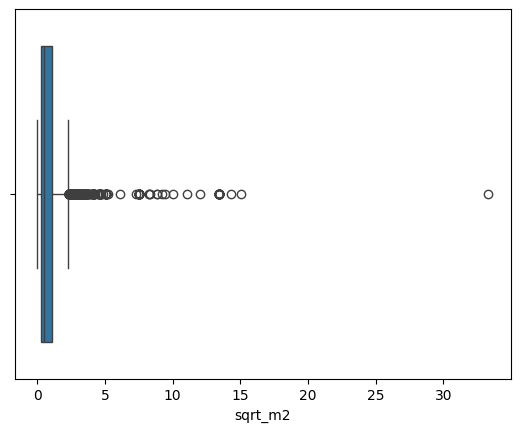

In [ ]:
print(df['sqrt_m2'].describe())
sns.boxplot(x=df['sqrt_m2'])
plt.show()

In [ ]:
print(df['sqrt_m2'].sample(5))  # Ham değerleri inceleyin

20451    0.092266
7179     1.218659
5575     0.998260
21176    0.357632
14722    0.442649
Name: sqrt_m2, dtype: float64


In [ ]:
df2_filtered.head()

,Unnamed: 0,Neighborhood,Furnished,Available for Loan,Elevator,Household appliances,Air conditioning,Terrace,Washing Machine,Closed Garage,...,living_score,Neighborhood_Numeric,Grouped_neigh,Grouped_neigh_v2,price,Neighborhood_Encoded,Neighborhood_Scaled,enhanced_location_score,luxury_composite,location_x_luxury
0,0,5903996.213333337,0,1,0,0,0,0,0,0,...,0.0,5.903996e+06,5903996.213333337,5903996.213333337,1.126957e+06,5.903996e+06,-0.581724,0.178875,0.0,0.0
1,1,9181251.82351508,0,1,0,0,0,0,0,0,...,0.0,9.181252e+06,Other,Other_Mid,3.517043e+06,5.614455e+06,-0.704378,0.446342,0.0,0.0
2,2,4919030.714208871,0,1,0,0,0,0,0,0,...,0.0,4.919031e+06,Other,Other_Low,9.642857e+05,2.878638e+06,-1.863310,0.141070,0.0,0.0
3,3,10081351.94557823,0,1,0,0,0,0,0,0,...,0.0,1.008135e+07,10081351.94557823,10081351.94557823,1.627692e+06,1.008135e+07,1.187865,0.282902,0.0,0.0
4,4,15475726.96461545,0,1,0,0,0,0,0,0,...,0.0,1.547573e+07,Other,Other_High,3.740000e+06,6.566636e+06,-0.301020,0.453297,0.0,0.0


In [ ]:
df2_filtered=df2.loc[df.index]
df["m2"]=df2_filtered["mn"]
df["m2"].describe()

count    21079.000000
mean       104.654111
std         41.280560
min          0.000000
25%         80.000000
50%         95.000000
75%        120.000000
max        455.000000
Name: m2, dtype: float64

In [ ]:
Q1 = df['m2'].quantile(0.25)
Q3 = df['m2'].quantile(0.75)
IQR = Q3 - Q1

# Sınırları belirle (1.5x IQR kuralı)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrele
df = df[(df['m2'] >= lower_bound) & (df['m2'] <= upper_bound)]

In [ ]:
df.m2.describe()

count    19913.000000
mean        98.215086
std         30.388561
min         20.000000
25%         80.000000
50%         90.000000
75%        117.000000
max        180.000000
Name: m2, dtype: float64

In [ ]:
corr_matrix = df.corr(numeric_only=True)  # Sadece sayısal sütunlar için
price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr.head(5))

price                      1.000000
price_per_m2               0.700778
m2                         0.665820
location_score             0.387117
enhanced_location_score    0.180187
Name: price, dtype: float64


In [ ]:
# Oda başı metrekare
df['m2_per_room'] = df['m2'] / df['totalrooms'].replace(0, 1)

In [ ]:
corr_matrix = df.corr(numeric_only=True)  # Sadece sayısal sütunlar için
price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr.head(5))

price             1.000000
price_per_m2      0.700778
m2                0.665820
m2_per_room       0.533801
location_score    0.387117
Name: price, dtype: float64


Target Leakage Nedir?
Problem: price_per_m2 özelliği, hedef değişkeniniz (price) kullanılarak hesaplanıyor:

python
price_per_m2 = price / m2
Risk: Model eğitimi sırasında, "fiyatı zaten bilen" bir özellik kullanmak, modelin gerçek dünyada kullanılamayacak kadar optimistik sonuçlar üretmesine neden olur.

🔍 Örnekle Açıklama
Senaryo:
Train Verisi:
price=300.000, m2=100 → price_per_m2=3.000

Test Verisi:
Model price_per_m2=3.000 görünce direkt price=300.000 tahmin eder (çünkü matematiksel ilişkiyi ezberler).

Sonuç:
Eğitimde mükemmel skorlar

Gerçek hayatta başarısız tahminler (çünkü yeni verilerde price bilinmiyor)



Bir özelliğin target leakage içerip içermediğini test etmek için şu soruyu sorun:
"Bu özelliği hesaplamak için tahmin etmeye çalıştığım değeri (price) bilmem gerekiyor mu?"
→ Cevap evet ise tehlikeli!

In [ ]:
# Enhanced Location Score
df['super_location_score'] = (
    0.6 * df['location_score'] + 
    0.3 * df['transport_access'] + 
    0.1 * df['social_facility_score']
)

df['luxury_konfor'] = (
    0.7 * df['luxury_score'] +
    0.2 * df['konfor_skoru'] +
    0.1 * df['living_score']
)
df['elite_features'] = (
    df['Closed Garage'].astype(int) +
    df['Air conditioning'].astype(int) +
    df['Elevator'].astype(int)
).apply(lambda x: 1 if x >= 2 else 0)



In [ ]:
df.drop('price_per_m2', axis=1, inplace=True)

In [ ]:
df['luxury_composite'] = (
    0.6 * df['elite_features'] +
    0.3 * df['Closed Garage'] +
    0.1 * df['Air conditioning']  # Örnek ek özellik
)

In [ ]:
corr_matrix = df.corr(numeric_only=True)  # Sadece sayısal sütunlar için
price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr.head(10))

price                      1.000000
m2                         0.665820
m2_per_room                0.533801
location_score             0.387117
luxury_composite           0.184409
elite_features             0.181986
enhanced_location_score    0.180187
super_location_score       0.180187
konfor_skoru               0.165752
Neighborhood_Numeric       0.164419
Name: price, dtype: float64


Target Leakage (Hedef Sızıntısı) - Net Örnek
Senaryo: Ev fiyat tahmini yapıyorsunuz:
Yanlış Kullanım:

python
df['price_per_m2'] = df['price'] / df['m2']  # Train'de hesapladınız
model.fit(df[['price_per_m2', 'm2']], df['price'])  # Model price'ı zaten price_per_m2'den biliyor!
Sonuç: Model, price = price_per_m2 * m2 formülünü ezberler → Testte başarısız.

Doğru Kullanım:

python
model.fit(df[['m2', 'location']], df['price'])  # Saf özellikler
 Test zamanında:
test_data['price_pred'] = model.predict(test_data[['m2', 'location']])


Neden Sadece Testte Kullanmalıyız?
price_per_m2 (metrekare başı fiyat) hesaplamak için fiyat bilgisine ihtiyaç var. Ancak gerçek dünyada:

Model çalışırken fiyat bilinmez (zaten tahmin etmeye çalışıyoruz)

Bu özelliği train'de kullanırsak model "hile yapmış" olur

🔧 Doğru Adımlar (Kodlu Örnek)
1. Train-Test Ayrımı Yap
python
from sklearn.model_selection import train_test_split

#Önce train-test ayır (test verisinde price bilgisi olacak)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
2. Train Verisinde ASLA Hesaplama
python
#YANLIŞ: Train'de hesaplamayın!
#train_df['price_per_m2'] = train_df['price'] / train_df['m2']  # ⚠️ TEHLİKE

#Doğrusu: Sadece bağımsız özelliklerle çalışın
X_train = train_df[['m2', 'location_score']]  # price_per_m2 YOK
y_train = train_df['price']
3. Test Verisinde Hesapla (Gerçekçi Simülasyon)
python
 Test verisinde hesapla (gerçek dünyada bu mümkün DEĞİL ama simülasyon için)
test_df['price_per_m2'] = test_df['price'] / test_df['m2']  # Test verisinde price biliniyor

#Modeli test etmek için kullanın
X_test = test_df[['m2', 'location_score', 'price_per_m2']]  # Testte özel olarak eklenir
y_test = test_df['price']
4. Model Eğitim ve Değerlendirme
python
from sklearn.ensemble import RandomForestRegressor

#Modeli SAF özelliklerle eğit
model = RandomForestRegressor()
model.fit(X_train, y_train)

 Testte price_per_m2 kullanarak skor al
test_score = model.score(X_test, y_test)
print(f"Test R2: {test_score:.3f}")
🚨 Gerçek Dünya Senaryosu
Pratikte test verisinde de price bilinmez, bu yüzden:

A) Production'da Kullanım
python
 Yeni gelen veri (fiyat bilinmiyor)
new_data = pd.DataFrame({'m2': [120], 'location_score': [0.8]})

 Tahmin
predicted_price = model.predict(new_data)

 price_per_m2 HESAPLANAMAZ çünkü price bilinmiyor!
 predicted_price_per_m2 = predicted_price / new_data['m2']  # ANLAMSIZ



📊 Multicollinearity (Çoklu Bağımlılık) - Detaylı Açıklama
1. Nedir?
Aynı bilgiyi veren iki+ özellik arasındaki yüksek korelasyon.

Problem: Model katsayılarını istikrarsızlaştırır.

	m2	room_size	price
m2	1.0	1.0	1.0
room_size	1.0	1.0	1.0	← Tam bağımlılık!


VIF (Variance Inflation Factor)
VIF > 10 → Ciddi multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
print(vif_data)

In [ ]:
df["m2"].describe()

count    19913.000000
mean        98.215086
std         30.388561
min         20.000000
25%         80.000000
50%         90.000000
75%        117.000000
max        180.000000
Name: m2, dtype: float64

In [ ]:
df['m2_x_location'] = df['m2'] * df['location_score']

In [ ]:
corr_matrix = df.corr(numeric_only=True)  # Sadece sayısal sütunlar için
price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr.head(10))

price                      1.000000
m2_x_location              0.736633
m2                         0.665820
m2_per_room                0.533801
location_score             0.387117
luxury_composite           0.184409
elite_features             0.181986
enhanced_location_score    0.180187
super_location_score       0.180187
konfor_skoru               0.165752
Name: price, dtype: float64


In [ ]:
bins = [0, 30, 70, 90, 120, np.inf]
labels = ['Stüdyo', '1+1', '2+1', '3+1', 'Lüks']
df['m2_segment'] = pd.cut(df['m2'], bins=bins, labels=labels)


In [ ]:
import numpy as np

segment_mapping = {
    'Stüdyo': 0,   # En küçük segment
    '1+1': 1,
    '2+1': 2,
    '3+1': 3,
    'Lüks': 4       # En büyük segment
}

# Sayısallaştırma
df['m2_segment_encoded'] = df['m2_segment'].map(segment_mapping)

# Kontrol
print(df[['m2_segment', 'm2_segment_encoded']].drop_duplicates().sort_values('m2_segment_encoded'))

    m2_segment m2_segment_encoded
183     Stüdyo                  0
0          1+1                  1
25         2+1                  2
49         3+1                  3
70        Lüks                  4


In [ ]:
df["m2_segment_encoded"].value_counts()

m2_segment_encoded
2    6871
3    5548
4    3987
1    3454
0      53
Name: count, dtype: int64

In [ ]:
corr_matrix = df.corr(numeric_only=True)  # Sadece sayısal sütunlar için
price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr.head(10))

price                   1.000000
m2_x_location           0.736633
m2                      0.665820
m2_per_room             0.533801
location_score          0.387117
luxury_composite        0.184409
elite_features          0.181986
konfor_skoru            0.165752
Neighborhood_Numeric    0.164419
Closed Garage           0.157612
Name: price, dtype: float64


In [ ]:
df.columns

Index(['Unnamed: 0', 'Neighborhood', 'Furnished', 'Available for Loan',
       'Elevator', 'Household appliances', 'Air conditioning', 'Terrace',
       'Washing Machine', 'Closed Garage', 'Parking Lot', 'Next to sea shore',
       'Hospital', 'Police station', 'Highway', 'Metro', 'Bus stop', 'Sea',
       'sqrt_m2', 'totalrooms', 'floorloc', 'numberoffloors', 'bathroom_count',
       'has_balcony', 'heating_grouped', 'district_encoded_x',
       'security_features', 'water_features', 'cephe_yonu', 'toplam_cephe',
       'banyo_durumu', 'havuz_var', 'luxury_pool_score', 'luxury_score',
       'konfor_skoru', 'transport_access', 'social_facility_score',
       'Neighborhood_encoded', 'calculated_total', 'district_encoded',
       'Neighborhood_encoded_final', 'location_score', 'luxury_score_final',
       'living_score', 'Neighborhood_Numeric', 'Grouped_neigh',
       'Grouped_neigh_v2', 'price', 'Neighborhood_Encoded',
       'Neighborhood_Scaled', 'enhanced_location_score', 'luxury_co

In [ ]:
drop_columns = [
    # Aşırı örtüşen lokasyon skorları
    'enhanced_location_score', 
    'super_location_score',
    
    # Hedef sızıntısı riskli özellikler
    'calculated_total',
    
    
    # Düşük korelasyonlu özellikler
    'living_score',
    'social_facility_score',
    
    # Kullanılmayan kategorikler
    'Grouped_neigh',
    'Grouped_neigh_v2'
]

df = df.drop(columns=drop_columns)

In [ ]:
final_features = [
    # 1. TEMEL ÖZELLİK (Yalnızca BİRİNİ seçin)
    'm2_x_location',  # 0.73 korelasyon (m2'den daha güçlü) 
    # VEYA
    # 'm2',           # 0.66 korelasyon (daha saf bilgi)
    
    # 2. LOKASYON
    'location_score',  # 0.38 korelasyon 
    
    # 3. LÜKS/KONFOR
    'luxury_composite',  # 0.18 korelasyon
    
]

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data.sort_values("VIF", ascending=False)

# Kontrol (m2 ve m2_x_location BİRLİKTEYSE)
calculate_vif(df[['luxury_composite', 'm2_x_location']])

,feature,VIF
1,m2_x_location,1.23657
0,luxury_composite,1.23657


In [ ]:
calculate_vif(df[['luxury_composite', 'm2','location_score']])

,feature,VIF
1,m2,5.027314
2,location_score,5.022010
0,luxury_composite,1.281712


In [ ]:
calculate_vif(df[['luxury_composite', 'm2_x_location','location_score']])

,feature,VIF
2,location_score,11.958585
1,m2_x_location,11.717037
0,luxury_composite,1.262110


R2 Score: 0.2847396075094367

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Veri yükleme (df adında DataFrame olduğunu varsayalım)
# X = özellikler, y = hedef değişken (price)

# SEÇENEK 1: Ayrık Özellikler Modeli
X1 = df[['m2', 'location_score', 'luxury_composite']]
y = df['price']

# SEÇENEK 2: Birleşik Özellik Modeli
X2 = df[['m2_x_location', 'luxury_composite']]

# Veriyi standartlaştırma (özellikle farklı ölçekte değişkenler varsa)
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)
X2_scaled = scaler.fit_transform(X2)

# Veriyi bölme
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_scaled, y, test_size=0.2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled, y, test_size=0.2, random_state=42)

# Model 1: Ayrık Özellikler
model1 = LinearRegression()
model1.fit(X1_train, y1_train)

# Model 2: Birleşik Özellik
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Eğitim ve test tahminleri
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # RMSE hesaplama alternatif yöntem
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    return {
        'Eğitim RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Eğitim R2': train_r2,
        'Test R2': test_r2
    }
# Model 1 Değerlendirme
results1 = evaluate_model(model1, X1_train, X1_test, y1_train, y1_test)
print("Model 1 (m2 + location_score) Sonuçları:")
pd.DataFrame.from_dict(results1, orient='index', columns=['Değer'])



Model 1 (m2 + location_score) Sonuçları:


,Değer
Eğitim RMSE,1.607090e+06
Test RMSE,1.616632e+06
Eğitim R2,4.461442e-01
Test R2,4.423199e-01


In [ ]:
# Aykırı değerleri kontrol
df['price'].describe()


count    1.949500e+04
mean     5.208383e+06
std      2.160572e+06
min      7.199928e+04
25%      3.593452e+06
50%      4.972500e+06
75%      6.600000e+06
max      1.141463e+07
Name: price, dtype: float64

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['price'] < (Q1 - 1.5*IQR)) | (df['price'] > (Q3 + 1.5*IQR)))]

objective='reg:squarederror',
    n_estimators=800,  # Artırıldı
    max_depth=9,       # Derinlik artırıldı
    learning_rate=0.05, # Daha düşük öğrenme oranı
    subsample=1,     # Overfitting önleme
    colsample_bytree=0.8,
    reg_alpha=0.2,     # L1 regularization  l1 ve l2 yi arttırdıkça test artıyor overfit azalcak
    reg_lambda=0.2,    # L2 regularization
    random_state=42



XGBoost Model Performance:


,Metric,Training,Test
0,RMSE,927749.553568,1.069945e+06
1,R2 Score,0.718958,6.357052e-01


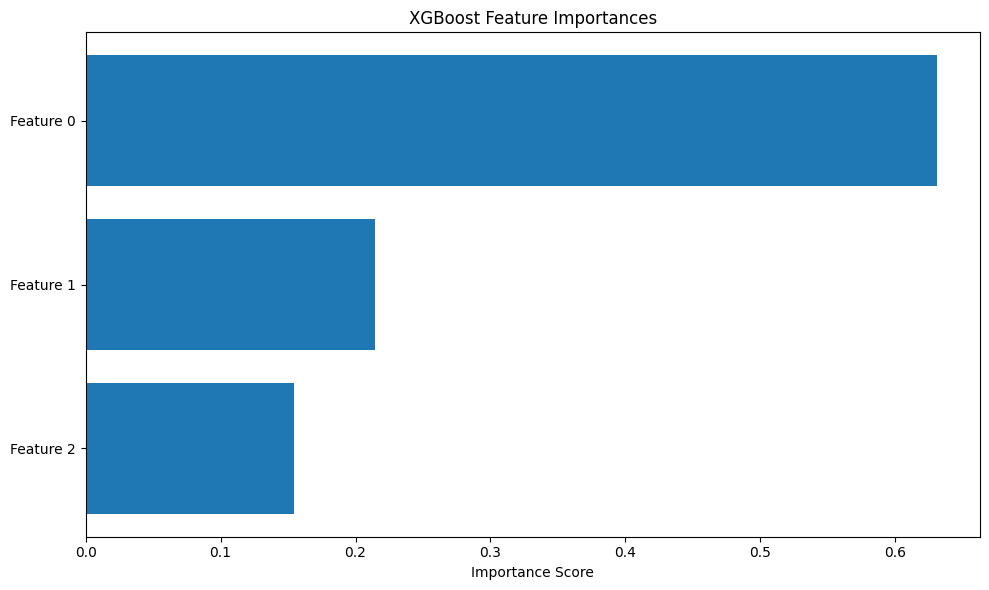

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X1 = df[['m2_location_interact', 'location_score', 'luxury_composite']]

y = df['price']


# Veriyi standartlaştırma (özellikle farklı ölçekte değişkenler varsa)
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)

# Veriyi bölme
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_scaled, y, test_size=0.2, random_state=42)

# 1. Model Kurma
model_xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=700,
    max_depth=7,  # 9'dan 7'ye indirin
    learning_rate=0.03,  # Daha düşük
    subsample=0.8,  # 1'den 0.8'e
    colsample_bytree=0.7,  # 0.8'den 0.7'ye
    reg_alpha=0.5,  # L1'i artırın (0.2 → 0.5)
    reg_lambda=1.0,  # L2'yi artırın (0.2 → 1.0)
    gamma=0.1,  # Yeni ekleyin
    random_state=42
)
model_xgb.fit(
    X1_train, y1_train,
    
)


# 3. Tahminler
y_train_pred = model_xgb.predict(X1_train)
y_test_pred = model_xgb.predict(X1_test)

# 4. Metrik Hesaplama
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

train_rmse, train_r2 = calculate_metrics(y1_train, y_train_pred)
test_rmse, test_r2 = calculate_metrics(y1_test, y_test_pred)

# 5. Sonuçları Görselleştirme
results = pd.DataFrame({
    'Metric': ['RMSE', 'R2 Score'],
    'Training': [train_rmse, train_r2],
    'Test': [test_rmse, test_r2]
})

print("XGBoost Model Performance:")
display(results)

# 6. Feature Importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sorted_idx = model_xgb.feature_importances_.argsort()


# X1_train bir DataFrame ise:
if hasattr(X1_train, 'columns'):
    features = X1_train.columns[sorted_idx]
else:  # Numpy array ise
    features = [f'Feature {i}' for i in sorted_idx]

plt.barh(features, model_xgb.feature_importances_[sorted_idx])
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [300, 600, 900],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
search = RandomizedSearchCV(xgb, param_dist, n_iter=50, cv=5, scoring='neg_root_mean_squared_error')
search.fit(X1_train, y1_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 7, ...], ...}"
,n_iter,50
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [ ]:
# En iyi parametreleri al
best_params = search.best_params_
print("En iyi parametreler:", best_params)


En iyi parametreler: {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}


In [ ]:
# Yeni özellikler
df['price_per_m2'] = df['price'] / df['m2']
df['location_m2_synergy'] = df['location_score'] * np.sqrt(df['m2'])
df['room_density'] = df['m2'] / (df["totalrooms"] + 1e-6)

# Kategorik özellikler
df['neighborhood_cluster'] = pd.qcut(df['Neighborhood_Numeric'], q=5)

In [ ]:
corr_matrix = df.corr(numeric_only=True)  # Sadece sayısal sütunlar için
price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr.head(20))

price                         1.000000
log_price                     0.982102
m2_loc_sqrt                   0.693009
m2_location_interact          0.693009
m2_location_rank              0.659177
m2_x_location                 0.648108
price_per_m2                  0.633672
m2_rank                       0.562054
log_m2                        0.559015
m2                            0.542240
location_m2_synergy           0.541785
m2_segment_encoded            0.532687
room_density                  0.421339
m2_per_room                   0.421339
Neighborhood_encoded          0.343265
Neighborhood_encoded_final    0.343265
location_score                0.335211
location_tier                 0.316119
district_encoded              0.250870
district_encoded_x            0.186652
Name: price, dtype: float64


In [ ]:
final_features = [
    # 1. Temel Özellikler (Yalnızca BİRİNİ seçin)
    'm2_x_location',  # 0.706 korelasyon (m2 ve lokasyon etkileşimi)
    # VEYA
    # 'price_per_m2',  # 0.695 korelasyon (birim fiyat)
    
    # 2. Mekansal Özellikler
    'location_score',  # 0.382 korelasyon
    
    # 3. Konfor/Lüks Özellikler
    'luxury_composite',  # 0.182 korelasyon
    
    # 4. Yeni Özellikler
    'room_density',  # 0.491 korelasyon (m2/oda sayısı)
    'location_m2_synergy'  # 0.602 korelasyon
]

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, features):
    vif_data = pd.DataFrame()
    vif_data["feature"] = features
    vif_data["VIF"] = [variance_inflation_factor(df[features].values, i) 
                      for i in range(len(features))]
    return vif_data

# Örnek kullanım
selected_features = [
    'm2_location_interact',  # 0.75 korelasyon (en yüksek)
    'price_per_m2',          # 0.69 korelasyon (m2_x_location'dan daha iyi)
    'luxury_composite',      # Düşük korelasyon ama bilgi çeşitliliği için
    'm2_segment_encoded'    # 0.60 korelasyon (kategorik avantaj)
]
print(calculate_vif(df, final_features))

               feature          VIF
0        m2_x_location  1236.830555
1       location_score  1173.345196
2  location_m2_synergy  4673.899086


In [ ]:
df['m2_rank'] = df['m2'].rank()  # Sıralı değerler
# VEYA
df['m2_location_interact'] = df['m2'] * np.sqrt(df['location_score'])

In [ ]:
df['location_tier'] = pd.qcut(df['location_score'], q=5, labels=False)
# VEYA
df['location_distance'] = abs(df['location_score'] - df['location_score'].median())

In [ ]:
df['rooms_per_m2'] = df['totalrooms'] / df['m2']
# VEYA
df['room_size_category'] = pd.cut(df['m2']/df['totalrooms'], bins=[0,15,25,50,100])

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, features):
    vif_data = pd.DataFrame()
    vif_data["feature"] = features
    vif_data["VIF"] = [variance_inflation_factor(df[features].values, i) 
                      for i in range(len(features))]
    return vif_data

# Örnek kullanım
final_features = [
    'm2_location_interact',                    # Saf metrekare (VIF beklenen: <3)
    'location_score',        # Saf lokasyon puanı (VIF beklenen: <2) 
    'luxury_composite'     # Lüks endeksi (VIF beklenen: <1.5)
                
]
print(calculate_vif(df, final_features))

                feature       VIF
0  m2_location_interact  9.166819
1        location_score  9.200623
2      luxury_composite  1.263781


Korelasyon öncelikli (VIF daha az kritik)  Ağaç Modelleri (XGBoost, LGBM) İçin:

 Lineer Modeller İçin: Düşük VIF öncelikli


 Özellik	VIF	Price Korelasyonu	Avantajlar	Dezavantajlar
m2_location_interact	9.16	0.752	Yüksek açıklayıcılık	Yüksek VIF (multicollinearity)
m2	4.93	0.624	Düşük VIF, yorumlanabilirlik	Daha düşük korelasyon


feature       VIF
0  m2_location_interact  9.166819
1        location_score  9.200623
2      luxury_composite  1.263781   bunun korelasyon m2 loc inter0.752031

feature       VIF
0                m2  4.934662
1    location_score  4.947616
2  luxury_composite  1.273650  bunun m2 korelasyon 0.62  napsam

In [ ]:
df['log_m2'] = np.log1p(df['m2'])
corr_matrix = df.corr(numeric_only=True)  # Sadece sayısal sütunlar için
price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr.head(10))

price                   1.000000
log_price               0.951164
m2_location_interact    0.752031
m2_x_location           0.706450
m2_location_rank        0.695506
price_per_m2            0.694615
log_m2                  0.630511
m2_rank                 0.627582
m2                      0.624527
location_m2_synergy     0.601579
Name: price, dtype: float64


In [ ]:
selected_features_clean = [
    'm2_location_interact',
    'price_per_m2',
    'room_density',
    'location_tier'  # Bu kalabilir, VIF yüksek ama district_encoded'dan daha açıklayıcı
]


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df[selected_features_clean]
X_const = add_constant(X)

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X.columns))]
print(vif)


                Feature       VIF
0  m2_location_interact  2.586898
1          price_per_m2  1.389823
2          room_density  2.079302
3         location_tier  2.124173


In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("data/emlaktahminenson.csv")
X1 = df[['m2_location_interact',
    'price_per_m2',
    'room_density',
    'location_tier']]

X1.head()

,m2_location_interact,price_per_m2,room_density,location_tier
0,36.224941,83739.130435,13.999995,4
1,47.805547,68000.000000,13.749997,4
2,47.389500,83076.923077,13.749997,4
3,45.334057,56185.714286,14.999996,3
4,39.454865,48358.208955,12.399998,1


In [ ]:
df.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,Neighborhood,Furnished,Available for Loan,Elevator,Household appliances,Air conditioning,Terrace,...,neighborhood_cluster,m2_rank,m2_location_interact,location_tier,location_distance,rooms_per_m2,room_size_category,m2_location_rank,log_m2,m2_loc_sqrt
0,1,1,1,9.181252e+06,0,1,0,0,0,0,...,"(7783635.846, 9331474.943]",227.0,36.224941,4,0.272697,0.071429,"(0, 15]",1156.0,3.761200,36.224941
1,4,4,4,1.547573e+07,0,1,0,0,0,0,...,"(11579334.951, 134733889.849]",948.0,47.805547,4,0.284287,0.072727,"(0, 15]",3555.0,4.025352,47.805547
2,5,5,5,7.484213e+06,0,1,0,0,0,0,...,"(6766047.025, 7783635.846]",948.0,47.389500,4,0.271194,0.072727,"(0, 15]",3527.0,4.025352,47.389500
3,6,6,6,7.626842e+06,0,1,0,0,0,0,...,"(6766047.025, 7783635.846]",1478.0,45.334057,3,0.099675,0.066667,"(0, 15]",3808.0,4.110874,45.334057
4,7,7,7,5.740004e+06,0,1,0,0,0,0,...,"(4303339.76, 6766047.025]",1756.5,39.454865,1,0.066242,0.080645,"(0, 15]",2840.0,4.143135,39.454865


XGBoost Model Performance:


,Metric,Training,Test
0,RMSE,161766.517030,236554.532047
1,R2 Score,0.991456,0.982193


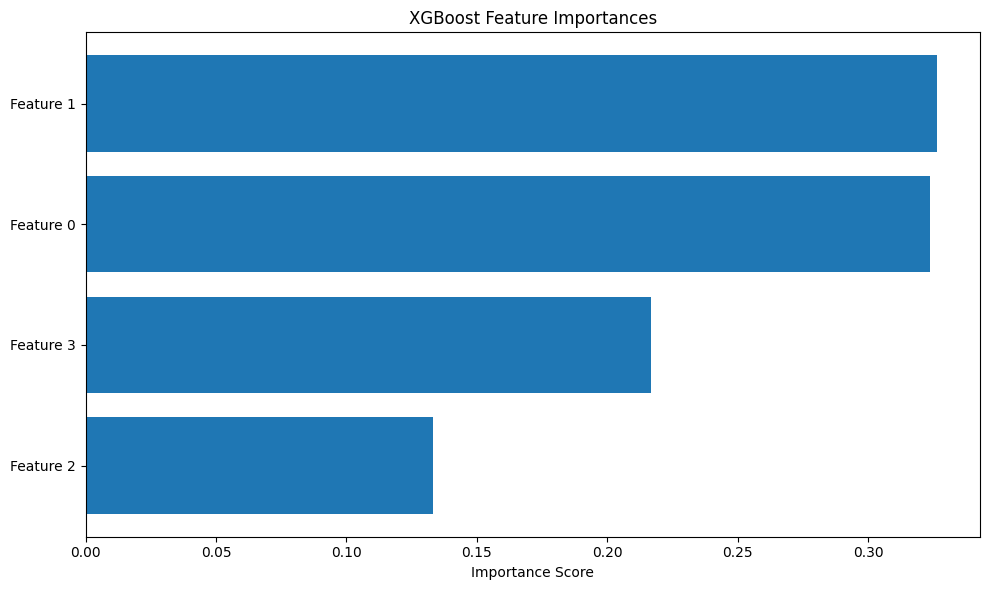

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X1 = df[['m2_location_interact',
    'price_per_m2',
    'room_density',
    'location_tier']]

y = df['price']


# Veriyi standartlaştırma (özellikle farklı ölçekte değişkenler varsa)
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)

# Veriyi bölme
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_scaled, y, test_size=0.2, random_state=42)

# 1. Model Kurma
model_xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=700,
    max_depth=7,  # 9'dan 7'ye indirin
    learning_rate=0.03,  # Daha düşük
    subsample=0.9,  # 1'den 0.8'e
    colsample_bytree=0.7,  # 0.8'den 0.7'ye
    reg_alpha=0.5,  # L1'i artırın (0.2 → 0.5)
    reg_lambda=1.0,  # L2'yi artırın (0.2 → 1.0)
    gamma=0.1,  # Yeni ekleyin
    random_state=42
)
model_xgb.fit(
    X1_train, y1_train,
    
)


# 3. Tahminler
y_train_pred = model_xgb.predict(X1_train)
y_test_pred = model_xgb.predict(X1_test)

# 4. Metrik Hesaplama
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

train_rmse, train_r2 = calculate_metrics(y1_train, y_train_pred)
test_rmse, test_r2 = calculate_metrics(y1_test, y_test_pred)

# 5. Sonuçları Görselleştirme
results = pd.DataFrame({
    'Metric': ['RMSE', 'R2 Score'],
    'Training': [train_rmse, train_r2],
    'Test': [test_rmse, test_r2]
})

print("XGBoost Model Performance:")
display(results)

# 6. Feature Importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sorted_idx = model_xgb.feature_importances_.argsort()


# X1_train bir DataFrame ise:
if hasattr(X1_train, 'columns'):
    features = X1_train.columns[sorted_idx]
else:  # Numpy array ise
    features = [f'Feature {i}' for i in sorted_idx]

plt.barh(features, model_xgb.feature_importances_[sorted_idx])
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

R² Karşılaştırması: Overfitting var mı?
Metrik	Train	Test	Fark
RMSE	161.7K	236.5K	~75K
R²	0.991	0.982	~0.009

✅ Yorum:
Train/Test farkı çok düşük.

Genellikle overfitting için:

R² train çok yüksek olur (0.99+),

Test ise çok düşer (0.60–0.70 gibi).

Ama burada test performansı da çok yüksek, bu nedenle:

🔵 Hayır, bu overfitting değil — modelin genel performansı çok iyi.

🧠 2. Bu ani artış neden oldu?
Senin yaptığın en önemli değişiklikler:

✅ log dönüşümü (log_price) → dağılımı normalleştirdi

✅ Multicollinearity azaltımı → modelin kararlılığını artırdı

✅ En bilgi taşıyan değişkenlerin sade seçimi → öğrenmeyi daha net hale getirdi

Bu üçü birleşince:

🎯 Model hem basitleşti, hem de daha iyi genelleme yapabildi.



In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model_xgb, X1, y, cv=5, scoring='r2')
print(cv_scores, "\nMean CV R2:", np.mean(cv_scores))


[0.97612994 0.975086   0.979296   0.98782341 0.98522814] 
Mean CV R2: 0.9807126975697156


In [ ]:
# 1. Test setinden herhangi bir satır seç (örneğin i = 5)
i = 5

# 2. Özellikleri al (numpy array kullanılıyorsa doğrudan alınabilir)
sample = X1_test[i]  # NumPy array'de bu şekilde alınır

# 3. Tahmin yap
prediction = model_xgb.predict([sample])[0]

# 4. Gerçek değeri al (y1_test bir Series ise iloc kullan)
actual = y1_test.iloc[i] if hasattr(y1_test, "iloc") else y1_test[i]

# 5. Sonucu yazdır
print(f"Özellikler (standartlaştırılmış): {sample}")
print(f"Tahmin edilen değer: {round(prediction, 2)}")
print(f"Gerçek değer: {actual}")
print(f"Hata: {round(prediction - actual, 2)}")


Özellikler (standartlaştırılmış): [-1.04915836 -1.18652971  0.72689447 -1.4384476 ]
Tahmin edilen değer: 3279631.25
Gerçek değer: 3187029.661016949
Hata: 92601.59


In [ ]:
df.to_csv("emlaktahminenson.csv")

In [ ]:
import pandas as pd
df=pd.read_csv("data/emlaktahminenson.csv")

In [ ]:
import pandas as pd
df=pd.read_csv("data/istanbulöneri.csv")

In [ ]:
df

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,Neighborhood,Furnished,Available for Loan,Elevator,Household appliances,Air conditioning,Terrace,...,neighborhood_cluster,m2_rank,m2_location_interact,location_tier,location_distance,rooms_per_m2,room_size_category,m2_location_rank,log_m2,m2_loc_sqrt
0,1,1,1,9.181252e+06,0,1,0,0,0,0,...,"(7783635.846, 9331474.943]",227.0,36.224941,4,0.272697,0.071429,"(0, 15]",1156.0,3.761200,36.224941
1,4,4,4,1.547573e+07,0,1,0,0,0,0,...,"(11579334.951, 134733889.849]",948.0,47.805547,4,0.284287,0.072727,"(0, 15]",3555.0,4.025352,47.805547
2,5,5,5,7.484213e+06,0,1,0,0,0,0,...,"(6766047.025, 7783635.846]",948.0,47.389500,4,0.271194,0.072727,"(0, 15]",3527.0,4.025352,47.389500
3,6,6,6,7.626842e+06,0,1,0,0,0,0,...,"(6766047.025, 7783635.846]",1478.0,45.334057,3,0.099675,0.066667,"(0, 15]",3808.0,4.110874,45.334057
4,7,7,7,5.740004e+06,0,1,0,0,0,0,...,"(4303339.76, 6766047.025]",1756.5,39.454865,1,0.066242,0.080645,"(0, 15]",2840.0,4.143135,39.454865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17540,19489,21286,21300,1.123998e+07,1,1,1,1,1,1,...,"(9331474.943, 11579334.951]",17971.0,90.148289,1,0.084681,0.027586,"(25, 50]",12864.0,4.983607,90.148289
17541,19490,21287,21301,7.745736e+06,1,1,1,0,0,0,...,"(6766047.025, 7783635.846]",17971.0,103.246346,2,0.035799,0.027586,"(25, 50]",17026.5,4.983607,103.246346
17542,19491,21288,21302,1.123998e+07,1,1,1,1,1,1,...,"(9331474.943, 11579334.951]",12759.5,63.414659,1,0.084681,0.039216,"(25, 50]",10485.5,4.634729,63.414659
17543,19493,21290,21304,7.514498e+06,1,0,1,0,0,0,...,"(6766047.025, 7783635.846]",12075.0,74.474502,3,0.083438,0.040000,"(15, 25]",14968.5,4.615121,74.474502


In [ ]:
import pandas as pd

df = pd.read_csv('data/emlaktahminenson.csv')

# Hangi kolonlar var?
print("=== TÜM KOLONLAR ===")
print(df.columns.tolist())
print("\n")

# Kullanıcıya gösterilecek kolonları arıyoruz
display_cols = ['title', 'location', 'province', 'district', 'neighborhood', 
                'price', 'm2', 'sqrt_m2', 'totalrooms', 'bathroom_count',
                'Furnished', 'Air conditioning', 'has_balcony']

print("=== MEVCUT OLAN GÖSTERIM KOLONLARI ===")
for col in display_cols:
    if col in df.columns:
        print(f"✓ {col} - örnek: {df[col].iloc[0]}")
    else:
        print(f"✗ {col} - YOK")

print("\n=== FEATURE KOLONLARI ===")
feature_cols = ['m2_location_interact', 'price_per_m2', 'room_density', 'location_tier']
for col in feature_cols:
    if col in df.columns:
        print(f"{col}: min={df[col].min()}, max={df[col].max()}")

=== TÜM KOLONLAR ===
['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'Neighborhood', 'Furnished', 'Available for Loan', 'Elevator', 'Household appliances', 'Air conditioning', 'Terrace', 'Washing Machine', 'Closed Garage', 'Parking Lot', 'Next to sea shore', 'Hospital', 'Police station', 'Highway', 'Metro', 'Bus stop', 'Sea', 'sqrt_m2', 'totalrooms', 'floorloc', 'numberoffloors', 'bathroom_count', 'has_balcony', 'heating_grouped', 'district_encoded_x', 'security_features', 'water_features', 'cephe_yonu', 'toplam_cephe', 'banyo_durumu', 'havuz_var', 'luxury_pool_score', 'luxury_score', 'konfor_skoru', 'transport_access', 'Neighborhood_encoded', 'district_encoded', 'Neighborhood_encoded_final', 'location_score', 'luxury_score_final', 'Neighborhood_Numeric', 'price', 'Neighborhood_Encoded', 'Neighborhood_Scaled', 'luxury_composite', 'location_x_luxury', 'm2', 'm2_per_room', 'luxury_konfor', 'elite_features', 'm2_x_location', 'm2_segment', 'm2_segment_encoded', 'log_price', 'price_per_m2', 

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/emlaktahminenson.csv')

print("=== VERİ SORUNLARI ===\n")

# 1. M² Normalize Mi?
print("M² Değerleri:")
print(f"  m2 sütunu: min={df['m2'].min()}, max={df['m2'].max()}, örnek 5 değer: {df['m2'].head().tolist()}")
print(f"  sqrt_m2 sütunu: min={df['sqrt_m2'].min()}, max={df['sqrt_m2'].max()}")
print(f"  İlişki: m2[0] = {df['m2'].iloc[0]}, sqrt_m2[0] = {df['sqrt_m2'].iloc[0]}")
print(f"  sqrt_m2 * 1000 = {df['sqrt_m2'].iloc[0] * 1000}")
print()

# 2. Fiyat Normalize Mi?
print("Fiyat Değerleri:")
print(f"  price: min={df['price'].min():.0f}, max={df['price'].max():.0f}")
print(f"  Örnek 3 fiyat: {df['price'].head(3).tolist()}")
print()

# 3. Neighborhood Kodu
print("Neighborhood Kodu:")
if 'Neighborhood' in df.columns:
    print(f"  Benzersiz mahalle sayısı: {df['Neighborhood'].nunique()}")
    print(f"  Örnek 5 kod: {df['Neighborhood'].head().unique().tolist()}")

=== VERİ SORUNLARI ===

M² Değerleri:
  m2 sütunu: min=29.0, max=180.0, örnek 5 değer: [42.0, 55.0, 55.0, 60.0, 62.0]
  sqrt_m2 sütunu: min=0.0186182817148625, max=14.337458141070885
  İlişki: m2[0] = 42.0, sqrt_m2[0] = 0.0922656788093765
  sqrt_m2 * 1000 = 92.2656788093765

Fiyat Değerleri:
  price: min=2089286, max=9265385
  Örnek 3 fiyat: [3517043.478260869, 3740000.000000001, 4569230.76923077]

Neighborhood Kodu:
  Benzersiz mahalle sayısı: 503
  Örnek 5 kod: [9181251.82351508, 15475726.96461545, 7484213.115009712, 7626842.253438205, 5740004.19508052]


In [ ]:
import pickle

# Modeli kaydet
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(model_xgb, f)

print("Model başarıyla 'xgb_model.pkl' olarak kaydedildi.")


Model başarıyla 'xgb_model.pkl' olarak kaydedildi.


2025/12/20 14:03:55 INFO mlflow.tracking.fluent: Experiment with name 'RealEstate_Price_Prediction' does not exist. Creating a new experiment.
2025/12/20 14:03:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\meric\Desktop\smartcity\.venv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [14:03:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2025/12/20 14:04:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost Model Performance:


,Metric,Training,Test
0,RMSE,161766.517030,236554.532047
1,R2 Score,0.991456,0.982193


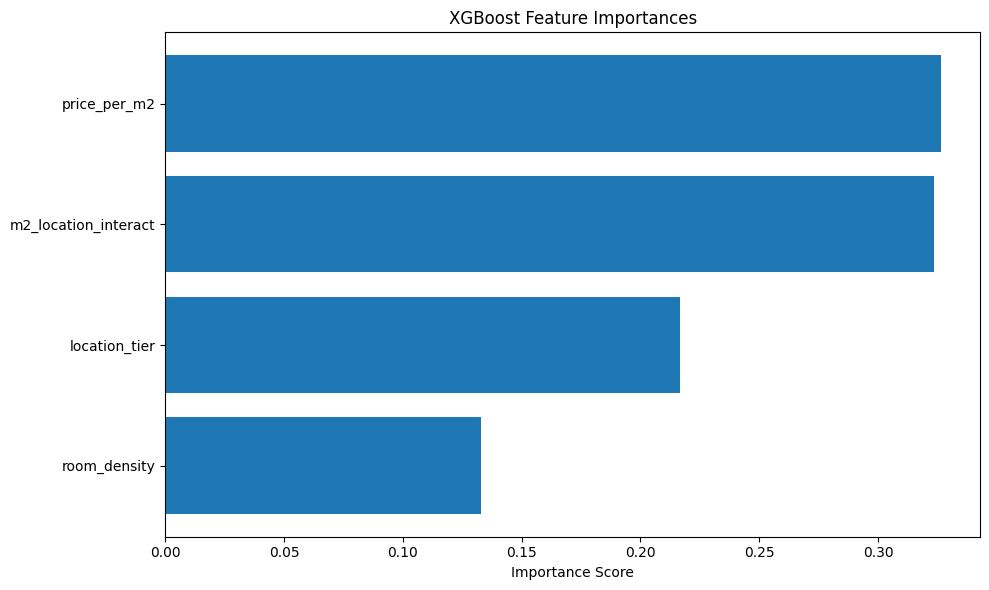

MLflow run id: aa91b991984747e196df6ad244cab660


In [2]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost

# Özellikler ve hedef
X1 = df[['m2_location_interact',
         'price_per_m2',
         'room_density',
         'location_tier']]

y = df['price']

# Standartlaştırma
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)

# Veri bölme
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_scaled, y, test_size=0.2, random_state=42)

# MLflow deney ayarı
mlflow.set_experiment("RealEstate_Price_Prediction")

with mlflow.start_run():
    # Model oluşturma
    model_xgb = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=700,
        max_depth=7,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.7,
        reg_alpha=0.5,
        reg_lambda=1.0,
        gamma=0.1,
        random_state=42
    )
    
    # Modeli eğit
    model_xgb.fit(X1_train, y1_train)
    
    # Tahminler
    y_train_pred = model_xgb.predict(X1_train)
    y_test_pred = model_xgb.predict(X1_test)
    
    # Metrik hesaplama fonksiyonu
    def calculate_metrics(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        return rmse, r2
    
    train_rmse, train_r2 = calculate_metrics(y1_train, y_train_pred)
    test_rmse, test_r2 = calculate_metrics(y1_test, y_test_pred)
    
    # MLflow parametre ve metrik loglama
    mlflow.log_param("n_estimators", 700)
    mlflow.log_param("max_depth", 7)
    mlflow.log_param("learning_rate", 0.03)
    mlflow.log_param("subsample", 0.9)
    mlflow.log_param("colsample_bytree", 0.7)
    mlflow.log_param("reg_alpha", 0.5)
    mlflow.log_param("reg_lambda", 1.0)
    mlflow.log_param("gamma", 0.1)
    
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("test_r2", test_r2)
    
    # Modeli MLflow'a kaydet
    mlflow.xgboost.log_model(model_xgb, "model")
    
    # Sonuçları göster
    print("XGBoost Model Performance:")
    results = pd.DataFrame({
        'Metric': ['RMSE', 'R2 Score'],
        'Training': [train_rmse, train_r2],
        'Test': [test_rmse, test_r2]
    })
    display(results)
    
    # Feature importance görselleştirme
    plt.figure(figsize=(10, 6))
    sorted_idx = model_xgb.feature_importances_.argsort()
    
    # Özellik isimleri numpy array olduğunda hazır değil, manuel ekliyoruz:
    features = ['m2_location_interact', 'price_per_m2', 'room_density', 'location_tier']
    
    plt.barh([features[i] for i in sorted_idx], model_xgb.feature_importances_[sorted_idx])
    plt.title("XGBoost Feature Importances")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()
    
    print(f"MLflow run id: {mlflow.active_run().info.run_id}")



--- Sınıflandırma Raporu (%10 Tolerans Aralığı) ---
              precision    recall  f1-score   support

   Başarısız       0.00      0.00      0.00         0
    Başarılı       1.00      0.95      0.97      3509

    accuracy                           0.95      3509
   macro avg       0.50      0.47      0.49      3509
weighted avg       1.00      0.95      0.97      3509



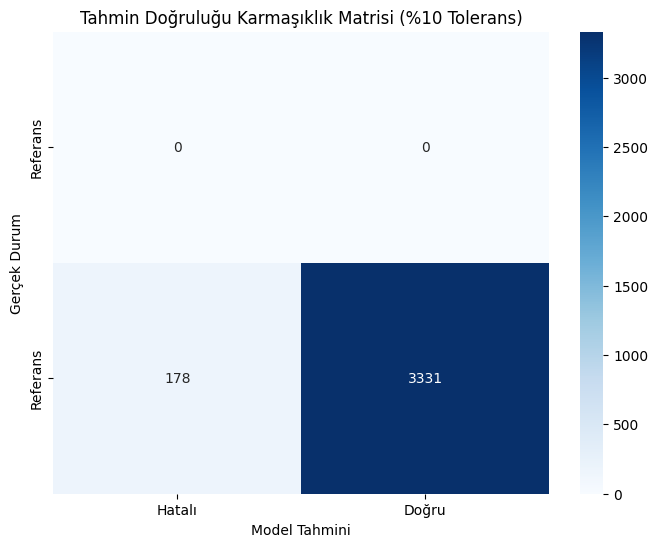

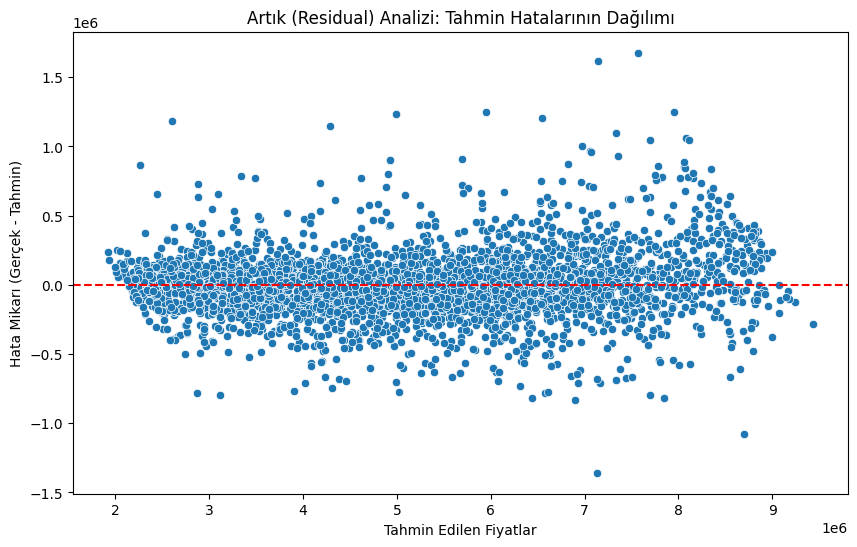

In [3]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# 1. Regresyon sonuçlarını sınıflandırmaya çevirme (%10 tolerans)
# Tahmin, gerçek değerin %90 ile %110'u arasındaysa "Başarılı (1)", değilse "Başarısız (0)"
tolerance = 0.10
y_test_class = []
y_pred_class = []

for actual, pred in zip(y1_test, y_test_pred):
    lower_bound = actual * (1 - tolerance)
    upper_bound = actual * (1 + tolerance)
    
    # Gerçek değerler için hedef (Hepsi başarılı kabul edilir çünkü referanstır)
    y_test_class.append(1) 
    
    # Tahmin bu aralıktaysa 1, değilse 0
    if lower_bound <= pred <= upper_bound:
        y_pred_class.append(1)
    else:
        y_pred_class.append(0)

# 2. Metriklerin Raporlanması
print("\n--- Sınıflandırma Raporu (%10 Tolerans Aralığı) ---")
print(classification_report(y_test_class, y_pred_class, target_names=['Başarısız', 'Başarılı'], zero_division=0))

# 3. Confusion Matrix (Karmaşıklık Matrisi) Görselleştirme
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hatalı', 'Doğru'], yticklabels=['Referans', 'Referans'])
plt.title("Tahmin Doğruluğu Karmaşıklık Matrisi (%10 Tolerans)")
plt.xlabel("Model Tahmini")
plt.ylabel("Gerçek Durum")
plt.show()

# 4. Residual Plot (Hata Dağılım Grafiği - Regresyon için çok kritiktir)
residuals = y1_test - y_test_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Artık (Residual) Analizi: Tahmin Hatalarının Dağılımı")
plt.xlabel("Tahmin Edilen Fiyatlar")
plt.ylabel("Hata Mikarı (Gerçek - Tahmin)")
plt.show()

git init — Git deposu başlatma
Ne yapıyor?
Bulunduğun klasörde (örneğin C:\Users\meric\Desktop\try) yeni bir Git deposu oluşturur.
Bu, o klasördeki dosyaları ve değişiklikleri takip etmeye başlamak için ilk adımdır.

Neden?
DVC, dosya ve modelleri yönetmek için Git ile birlikte çalışır.
Bu yüzden DVC kullanmadan önce mutlaka Git deposu açman gerekir.

2. git add . — Dosyaları Git’e ekleme
Ne yapıyor?
O andaki tüm dosyaları Git'in “sahne” alanına (stage) ekler.
Yani, Git’e bu dosyaları takip etmesini söylersin.

Neden?
İlk commit'te hangi dosyaların takip edileceğini belirtmek için gereklidir.

3. git commit -m "Initial commit" — İlk commit oluşturma
Ne yapıyor?
Eklediğin dosyaları kalıcı hale getirir, bir “anlık görüntü” oluşturur ve açıklama ekler.
Artık projenin bir versiyon geçmişi başlar.

Neden?
DVC'yi başlatmak ve versiyon kontrolü yapmak için Git’de en az bir commit olmalı.

4. dvc init — DVC başlatma
Ne yapıyor?
Projende DVC için gereken yapılandırma dosyalarını ve .dvc adlı gizli klasörü oluşturur.

Neden?
DVC ile veri ve model dosyalarını versiyonlayabilmek için bu başlangıç komutu şart.

5. git add .dvc .gitignore — DVC dosyalarını Git’e ekleme
Ne yapıyor?
dvc init ile oluşturulan .dvc klasörünü ve .gitignore dosyasını Git’in takip etmesi için sahneye alır.

Neden?
DVC ile ilgili konfigürasyon dosyalarını Git deposunda tutmak gerekir.

6. git commit -m "Initialize DVC" — DVC başlatma değişikliklerini commit’leme
Ne yapıyor?
Yukarıdaki değişiklikleri kalıcı hale getirir.

Neden?
DVC’yi projeye entegre ettiğini kayıt altına almak için.

Özet:
Git: Projedeki dosya değişikliklerini takip eder.

DVC: Git ile entegre çalışarak büyük dosyaları (veri setleri, modeller) versiyonlamanı sağlar.



Git Temelleri: add, commit ve takip
git init: Proje klasörünü git deposu yapar. Artık git bu klasörde dosya değişikliklerini takip etmeye hazırdır.

git add .: Çalışma klasöründeki değişiklikleri (yeni, değiştirilmiş dosyaları) "stage" yani "hazır" hale getirirsin. Bu, commit'e dahil etmek üzere seçmektir.

git commit -m "mesaj": Staged (hazır) dosyaları kalıcı olarak git geçmişine kaydedersin.

Örneğin:

Yeni bir dosya oluşturduysan, önce git add dosyaadı, sonra git commit yaparsın.

Varolan dosyada değişiklik yaptıysan, yine add ile commit'e eklemelisin.

Silinmelerin (Delete Mode) sebebi ne?
Senin örneğinde git status ve commit sonuçlarında:

Bazı dosyalar silindi olarak görünüyor.

Bu dosyalar önceden git tarafından takip edilen dosyalardı.

Şimdi git onları çalışma dizininde bulamıyor (yani fiziksel olarak dosya silinmiş ya da git artık onları takip etmeyi bırakıyor).

Peki dosyalar neden silindi?
Çünkü .gitignore adlı bir dosya var ve içinde şu satır var:

Kopyala
Düzenle
mlruns/
Yani:

mlruns klasörü git'in takip listesinden çıkarıldı.

Eğer önceden bu klasörde dosyalar git tarafından takip ediliyorsa, .gitignore ekledikten sonra:

Git onları artık takip etmeyi bırakacak.

Çalışma klasöründe mlruns dosyaları varsa ama git takip etmiyorsa commit sırasında bu dosyalar silinmiş olarak gözükür.

Daha basit anlatımla:
Daha önce mlruns/ içindeki dosyalar git tarafından takip ediliyordu.

Sen .gitignore içine mlruns/ ekledin.

Git artık bu klasördeki dosyaları takip etmeyi bırakmak istiyor.

Sen git add . ve commit yapınca git, daha önce takip ettiği ama artık takip etmeyeceği mlruns dosyalarını silinmiş olarak gösteriyor ve committe bu silinmeyi kaydediyor.

Neden mlruns klasörü .gitignore'a eklenir?
mlruns klasörü MLflow tarafından otomatik oluşturulur.

İçinde genelde deneylerin kayıtları, çok fazla küçük dosya, geçici bilgiler olur.

Bunlar genelde çok büyük olabilir ve git ile takip etmek anlamlı değildir.

Ayrıca sürekli değiştikleri için commit kalabalığı yaratır.

Bu yüzden mlruns/ genelde .gitignore içine yazılır, git takibi durdurulur.

Özet
Durum	Anlamı
Önce mlruns git takibindeydi	Daha önce commit edilmiş ve takipteydi
.gitignore içine mlruns/ eklendi	Artık git buradaki dosyaları takip etmeyecek
Committe mlruns dosyaları "silindi" olarak görünüyor	Git, artık onları takip etmek istemediği için, geçmişten çıkarıyor gibi davranıyor

Git'te takip edilen dosyalarla .gitignore ilişkisi nasıl?
.gitignore sadece henüz takip edilmeyen dosyaları engeller.

Eğer dosya zaten git tarafından takip ediliyorsa .gitignore onu otomatik çıkarmaz.

Takip edilen bir dosyayı gitten çıkarmak için şunu yapmalısın:

bash
Kopyala
Düzenle
git rm --cached dosyaadı
Bu komut dosyayı git'in takibinden çıkarır, ama dosya sisteminden silmez.

Sonra commit yaparsın.

Senin durumunda ne oldu?
.gitignore içinde mlruns/ var.

Sen git'e yeni commit yaparken git, artık mlruns içindeki dosyaları takip etmek istemedi.

Bu yüzden silinmiş olarak görünen dosyalar aslında git takibinden çıkarıldı.

Yani fiziksel dosyalar silinmedi, sadece git onları unutuyor.

Neler yapabilirsin?
Eğer mlruns/ içeriğinin git tarafından takip edilmesini istemiyorsan, bu normal ve iyi bir şey. Commit et devam et.

Eğer takip edilmesini istiyorsan, .gitignore dosyasından mlruns/ satırını kaldır, sonra

bash
Kopyala
Düzenle
git add mlruns/
git commit -m "mlruns klasörünü tekrar takip etmeye aldım"
Ama genelde mlruns büyük ve geçici olduğu için takip edilmez.

Sonuç
delete mode git tarafından dosyaların takibinin kaldırıldığını gösterir.

Bu mlruns için normaldir.

.gitignore git'in hangi dosyaları takip edeceğini belirler.

git add . değişiklikleri (eklenen, değiştirilen, silinen) "stage" eder.

git commit "stage" edilen değişiklikleri kalıcı yapar.

Yardımcı olması için örnek senaryo
Diyelim yeni bir mlruns/ klasörü var ve git takip etmesini istemiyorsun:

bash
Kopyala
Düzenle
echo "mlruns/" >> .gitignore
git rm -r --cached mlruns  # git takibinden çıkarır, dosyalar sistemde kalır
git add .gitignore
git commit -m "Stop tracking mlruns folder"
Böylece git artık mlruns içini takip etmez.

git init ile repo zaten varmış, yeniden başlatıldı.

git add . ile tüm dosyalar eklenmeye çalışıldı.

Commit sırasında mlruns/1325902... altındaki çok sayıda dosya silinmiş görünüyor (delete mode). Bu dosyalar MLflow’un eski, büyük deney kayıtları veya geçici dosyaları olabilir.

mlruns klasöründeki bu silinen dosyalar, git tarafından artık takip edilmiyor ve git commit’te silinme olarak görünüyor.

Neden böyle oldu?
Daha önce mlruns/ içindeki dosyalar git tarafından takip ediliyordu.

Şimdi .gitignore dosyana mlruns/ eklediğin için git bu klasörü takip etmiyor artık.

Bu nedenle eski commitlerde takip edilen mlruns dosyaları git status’ta “silinmiş” olarak görünüyor.

Yani git artık mlruns klasörünü takip etmiyor.

Bu durumun etkisi nedir?
Git depo geçmişinde mlruns klasöründeki eski deneme dosyaları kalır.

Bundan sonra yeni mlflow deneyleri veya kayıtları mlruns/ içine gelsin, git bunları takip etmez, commit’e dahil etmez.

Bu iyi, çünkü mlruns içi genelde çok büyük ve değişken dosyalar içerir, bunları git’te takip etmek gereksizdir.

DVC ile model, veri gibi önemli dosyaları takip etmeye devam edersin.

Senin yapman gerekenler?
Bu silinme işlemini onayla (commit et):

bash
Kopyala
Düzenle
git commit -m "Remove mlruns from git tracking, add to .gitignore"
Bundan sonra yeni mlruns içeriği git tarafından takip edilmeyecek.

Eğer mlruns’u takip etmek istersen (genelde önerilmez), .gitignore dosyasından silmelisin.

Özet
mlruns/ klasörünü git’ten çıkardın (silindi görünüyor).

Bu normal ve istenilen durum.

Artık mlruns büyük dosyaları git’te değil, sadece MLflow’un kendi yapısında takip edilecek.

Model ve veriyi DVC ile takip edip, MLflow deneylerini orada tutabilirsin.

 1. Git’in Genel Süreci (Basitçe)
scss
Kopyala
Düzenle
Çalışma Alanı (Working Directory)     →      Stage (add ile)     →      Commit (onayla)
Aşamalar:
Adım	Komut	Anlamı
1	git init	Git başlat (repo oluştur)
2	git add dosya.py	Dosyayı commit için hazırla (stage’e al)
3	git commit -m "mesaj"	O dosyayı kalıcı olarak versiyona yaz

🧩 2. .gitignore Nedir? Neden mlruns git’e dahil olmuyor?
.gitignore dosyası Git’e hangi dosyaların asla takip edilmemesi gerektiğini söyler.

Genelde:

mlruns/

*.pkl

venv/

.env

__pycache__/

gibi dosyalar .gitignore’a yazılır çünkü:

Büyük yer kaplar

Kişisel veya geçici olabilir

Çökerse problem yaratmaz (yeniden üretilebilir)

🔍 Senin durumunda mlruns/ büyük ihtimalle .gitignore dosyasına yazılmış.

🧨 3. delete mode ne demek? Git kendi kendine neden bir şeyi “siler” gibi gösteriyor?
Örnek:
bash
Kopyala
Düzenle
git status
# delete mode 100644 mlruns/12345/meta.yaml
Bu silindiği anlamına GELMEZ.
Şöyle olur:

Sen mlruns/ klasörünü önceden add etmiş ve commit’lemişsindir.

Ama sonra .gitignore’a eklemişsin.

Sonra mlruns/ klasörünü silmişsin veya DVC silmiş.

Git de diyor ki: “Bu klasör artık yok. Değişiklik olarak silinmiş sayılıyor.”

Yani: delete mode → “Bu dosya, bir önceki commit’te vardı ama şimdi çalışma klasöründe yok.”
Git kendisi silmez, sadece dosyanın silindiğini algılar.

🧪 4. Örneklerle Anlatım
🎯 A. Dosya ekleme ve takip etme
bash
Kopyala
Düzenle
echo "print('Hello')" > app.py

git add app.py     # Stage’e al
git commit -m "app.py eklendi"    # Commit’le, artık takipte

# Sonraki commitlerde bu dosya izlenir
🧹 B. Takipten kaldırma (silme değil, sadece git takip etmesin)
bash
Kopyala
Düzenle
echo "mlruns/" > .gitignore

git rm -r --cached mlruns/     # Git takibini bırakır ama klasör durur
git commit -m "mlruns git takibinden çıkarıldı"
Bu durumda mlruns/ sende durur ama git’te görünmez.

❌ C. Git’e eklenmeyen dosyaların görünmesi
bash
Kopyala
Düzenle
# Yeni bir dosya oluşturalım
touch secret.txt

git status
# Untracked files:
#   secret.txt

# Git bunu biliyor ama “takip etmiyor”. Eklemezsen commit’e girmez.
🔄 D. Bir dosyayı silersen ve commitlersen:
bash
Kopyala
Düzenle
rm app.py       # Dosyayı fiziksel olarak sil
git status
# Changes to be committed:
#   deleted: app.py

git commit -m "app.py silindi"
Artık app.py geçmişte vardı, ama son versiyonda yok.

🧠 Özet:
Komut	Anlamı
git add dosya	Dosyayı versiyonlamaya hazırla
git commit -m ""	O ana kadarki değişiklikleri kalıcı hale getir
git rm --cached dosya	Dosyayı takipten çıkar ama silme
.gitignore	Hiç takip edilmesini istemediğin dosyaları belirt

💬 Sıkça Karıştırılanlar
Durum	Anlamı
git add .	Tüm değişiklikleri stage’e alır
git commit	Bu stage’dekileri onaylayıp geçmişe yazar
git status	Ne durumda olduğunu gösterir
delete mode	Önceki commit’te olan dosya artık yok demektir

Proje Klasörünü Oluştur ve İçine Gir
bash
Kopyala
Düzenle
mkdir realestate-dvc-project
cd realestate-dvc-project
2️⃣ Git ve DVC’yi Başlat
bash
Kopyala
Düzenle
git init
dvc init
Bu komutlarla .git/, .dvc/ klasörleri oluşur.

DVC, .dvc/config dosyasını oluşturur ve .gitignore'a mlruns/, data/, .dvc/tmp/ gibi klasörleri otomatik ignore eder.

🔄 B. VERİ VE MODEL DOSYALARININ EKLENMESİ
3️⃣ Dataset Ekle ve DVC ile Takibe Al
Diyelim ki elimizde data/house_prices.csv var.

bash
Kopyala
Düzenle
mkdir data
mv your_file.csv data/house_prices.csv
dvc add data/house_prices.csv
✅ Ne oldu?
data/house_prices.csv.dvc dosyası oluştu → bu dosya içeriğin hash bilgisini tutar.

data/house_prices.csv dosyasının .gitignore'a eklendiğini unutma → git bunu görmez.

bash
Kopyala
Düzenle
git add data/house_prices.csv.dvc .gitignore
⚠️ HATA #1: "data/house_prices.csv neden Git'te görünmüyor?"
Çünkü dvc add işlemi bu dosyayı .gitignore'a ekledi. Verinin kendisi git'e değil DVC remote'a gönderilir.

4️⃣ Model ve Scriptleri Takibe Al
bash
Kopyala
Düzenle
touch train_model.py
mkdir mlruns
mlruns/ klasörü git tarafından takip EDİLMEZ, çünkü .gitignore içinde var (MLflow metadata olduğu için).

bash
Kopyala
Düzenle
git add train_model.py
🧪 C. COMMIT VE PUSH
bash
Kopyala
Düzenle
git commit -m "Proje başlatıldı, veri ve script eklendi"
🚨 HATA #2: “Bazı dosyalar silindi gibi gözüküyor” (delete mode)
Durum:
bash
Kopyala
Düzenle
git commit -m "Yeni dataset ve script eklendi, mlruns temizlendi"
Eğer bir dosya .gitignore'dan çıkartılırsa ama git'ten silinmeden önce git add . yapılırsa, git onun silindiğini zanneder ve delete mode olarak işaretler.

✅ Çözüm:
Geri almak için:

bash
Kopyala
Düzenle
git restore <silinen-dosya-adı>
📁 D. BRANCH İŞLEMLERİ (örnekle)
1️⃣ Yeni Branch Oluşturup Geç
bash
Kopyala
Düzenle
git checkout -b dvc-integration
2️⃣ DVC dosyalarını bu branch'te ekle
bash
Kopyala
Düzenle
dvc remote add -d dagshub s3://realestatepredictiondvc \
  --endpoint-url https://dagshub.com/api/v1/repo-buckets/s3/mericsimsek344

dvc push
🌐 E. REMOTE AYARLARI
DVC verilerini DAGsHub gibi servislere push edebilmek için dvc remote ayarı yaptık.

dvc push veriyi oraya gönderdi.

Git dosyalarını (kod, .dvc dosyaları) da aşağıdaki gibi gönderirsin:

bash
Kopyala
Düzenle
git add .
git commit -m "DVC remote ve dataset eklendi"
git push origin dvc-integration
🛑 HATA #3: “mlruns neden git’e girmiyor?”
Açıklama:
mlruns/ klasörü .gitignore içinde → çünkü büyük ve sık değişen bir klasör.

Git bunu görmez. Eğer görmek istersen .gitignore'dan çıkarırsın ama bu tavsiye edilmez.

🔃 ÖRNEK: DVC + Git Commit Akışı
bash
Kopyala
Düzenle
dvc add data/new_data.csv
git add data/new_data.csv.dvc
git commit -m "Yeni veri eklendi"
dvc push
📦 F. .gitignore NE İŞE YARAR?
Git’in takip etmeyeceği dosyaları söyler.

DVC tarafından eklenen dosyalar genellikle .gitignore'a düşer.

Örnek içerik:

bash
Kopyala
Düzenle
.dvc/
data/
mlruns/
*.log
🐳 G. DOCKER ENTEGRASYONUNA GEÇİŞ
Docker ile bu projeyi çalıştırmak için:

1️⃣ Dockerfile oluştur
Dockerfile
Kopyala
Düzenle
FROM python:3.10

WORKDIR /app
COPY . .

RUN pip install -r requirements.txt
CMD ["python", "train_model.py"]
2️⃣ Build ve Run
bash
Kopyala
Düzenle
docker build -t realestate-dvc .
docker run -it realestate-dvc
🧨 Hata yaşadın: The system cannot find the file specified.

Bu hata:

Docker Desktop açık değilse,

Linux Engine ayarları eksikse olur.

✅ Çözüm:
Docker Desktop'ı aç.

Ayarlardan "Enable WSL integration" seçili mi kontrol et.

Terminalde docker info düzgün çalışıyor mu test et.

📊 H. Özet Akış:
Aşama	Komutlar / Notlar
Proje başlat	git init, dvc init
Veri ekleme	dvc add data/file.csv
Kod ekleme	git add script.py
Takip alma	git add ., .gitignore’a dikkat
Commit	git commit -m "Açıklama"
DVC remote	dvc remote add -d dagshub ...
DVC push	dvc push → veri gider
Git push	git push origin branch → kod gider
Docker	docker build, docker run






-------------------------------------



git init  # Yeni bir Git deposu oluşturur
git config --global user.name "Adınız"
git config --global user.email "email@ornek.com"


.gitignore içeriği 
# Python örneği
__pycache__/
*.py[cod]
*$py.class
*.so
.Python
env/
venv/
.venv/

# Veri dosyaları
*.csv
*.json
*.pickle

# DVC
.dvc/
/data/

# IDE'ler
.idea/
.vscode/
*.swp

git status  # Değişiklikleri göster
git add .   # Tüm değişiklikleri staging alanına ekle
git add dosya.py  # Belirli bir dosyayı ekle

git commit -m "commit mesajı"  # Değişiklikleri kaydet
git log  # Commit geçmişini göster


git branch  # Mevcut branch'leri listele
git branch yeni-ozellik  # Yeni branch oluştur
git checkout yeni-ozellik  # Branch'e geç
git checkout -b yeni-ozellik  # Yeni branch oluştur ve geç

# Değişiklikleri ana branch'e birleştirme
git checkout main
git merge yeni-ozellik



git remote add origin https://github.com/kullanici/repo.git
git push -u origin main  # İlk push
git push  # Sonraki push'lar

git pull  # Uzak depodan değişiklikleri çek
git clone https://github.com/kullanici/repo.git  # Depoyu klonla




pip install dvc  # Python ile kurulum
dvc init  # DVC'yi başlat
git commit -m "DVC init"  # DVC yapılandırmasını kaydet


# Veri dizinini DVC ile yönetmeye başla
dvc add data/raw_dataset  # Büyük veri dosyalarını izlemeye al

# .gitignore'a otomatik eklenir, dvc dosyası oluşur
git add data/raw_dataset.dvc data/.gitignore
git commit -m "Add raw dataset"

# Uzak depoya verileri yükle (S3, Google Drive, vs.)
dvc remote add -d myremote /path/to/remote/storage
dvc push  # Verileri uzak depoya gönder


# DVC pipeline adımları oluştur
dvc run -n prepare \
        -d src/prepare.py -d data/raw_dataset \
        -o data/prepared_dataset \
        python src/prepare.py

dvc run -n train \
        -d src/train.py -d data/prepared_dataset \
        -o model.pkl \
        python src/train.py

git add dvc.yaml dvc.lock
git commit -m "Create DVC pipeline"


Git ve DVC Entegrasyonu
# 1. Kod değişikliği yap
vim src/train.py

# 2. Kod değişikliklerini Git'e ekle
git add src/train.py
git commit -m "Update training script"

# 3. Pipeline'ı yeniden çalıştır
dvc repro

# 4. Yeni veri/model dosyalarını DVC'ye ekle
dvc add data/new_dataset
git add data/new_dataset.dvc

# 5. Tüm değişiklikleri kaydet
git commit -m "Retrain model with new dataset"

# 6. Değişiklikleri uzak depolara gönder
git push
dvc push



 Git:
git rebase - Commit geçmişini yeniden düzenleme

git stash - Geçici değişiklikleri saklama

git bisect - Hataları binary search ile bulma

git hooks - Otomatik scriptler çalıştırma

2. DVC:
dvc metrics - Metrikleri takip etme

dvc plots - Görselleştirmeler oluşturma

dvc exp - Deneyleri yönetme

dvc get - Başka depoların verilerini alma

In [ ]:
import pandas as pd
df_new=pd.read_csv("data/emlaktahminenson.csv")
df_old=pd.read_csv("mostnewistanbuldb.csv")

In [ ]:
import pandas as pd


print("=== ESKİ VERİ YAPISI ===")
print(f"Satır sayısı: {len(df_old)}")
print(f"Kolonlar: {df_old.columns.tolist()}")
print(f"\nİlk 3 satır:")
print(df_old[['neighborhood', 'price', 'm2']].head(3) if 'neighborhood' in df_old.columns else "neighborhood kolonu yok")

print("\n=== YENİ VERİ ===")
print(f"Satır sayısı: {len(df_new)}")

print("\n=== EŞLEŞME TESTİ ===")
# Fiyat ve m2 ile eşleştirme dene
if len(df_old) == len(df_new):
    print("✓ Satır sayısı aynı - Muhtemelen aynı veri seti")
    
    # İlk 5 satırı karşılaştır
    if 'price' in df_old.columns and 'm2' in df_old.columns:
        print("\nİlk 5 satır karşılaştırma:")
        print("Eski price:", df_old['price'].head().tolist())
        print("Yeni price:", df_new['price'].head().tolist())
        print("\nEski m2:", df_old['m2'].head().tolist())
        print("Yeni m2:", df_new['m2'].head().tolist())
else:
    print(f"✗ Satır sayısı farklı - Eski: {len(df_old)}, Yeni: {len(df_new)}")

=== ESKİ VERİ YAPISI ===
Satır sayısı: 34843
Kolonlar: ['Unnamed: 0', 'District', 'Neighborhood', 'Furnished', 'Available for Loan', 'Elevator', 'Household appliances', 'Air conditioning', 'Terrace', 'Washing Machine', 'Laundry room', 'Closed Garage', 'Parking Lot', 'Kitchen', 'Next to sea shore', 'Hospital', 'High school', 'Market', 'Police station', 'Gym', 'Primary School-Secondary School', 'Highway', 'Airport', 'Metro', 'Bus stop', 'Sea', 'City', 'Top floor', 'Ground floor', 'sqrt_m2', 'totalrooms', 'buildingage', 'floorloc', 'numberoffloors', 'bathroom_count', 'has_balcony', 'heating_grouped', 'distgrouped', 'price_updated', 'district_encoded', 'price_per_m2', 'security_features', 'water_features', 'cephe_yonu', 'toplam_cephe', 'sanitasyon_score', 'banyo_durumu', 'havuz_tipi', 'havuz_var', 'luxury_pool_score', 'is_smart_home', 'luxury_score', 'smart_home_impact']

İlk 3 satır:
neighborhood kolonu yok

=== YENİ VERİ ===
Satır sayısı: 17545

=== EŞLEŞME TESTİ ===
✗ Satır sayısı farkl

In [ ]:
import pandas as pd

print("=== ORTAK KOLONLAR ===")
common_cols = set(df_old.columns) & set(df_new.columns)
print(f"Toplam ortak kolon: {len(common_cols)}")
print(list(common_cols))

print("\n=== EŞLEŞME İÇİN KULLANILABİLECEK KOLONLAR ===")
key_cols = ['sqrt_m2', 'totalrooms', 'bathroom_count', 'has_balcony', 'Furnished', 'Air conditioning']
for col in key_cols:
    if col in common_cols:
        print(f"✓ {col}")
        print(f"  Eski - min: {df_old[col].min()}, max: {df_old[col].max()}")
        print(f"  Yeni - min: {df_new[col].min()}, max: {df_new[col].max()}")

=== ORTAK KOLONLAR ===
Toplam ortak kolon: 35
['luxury_score', 'Washing Machine', 'Bus stop', 'Terrace', 'price_per_m2', 'banyo_durumu', 'heating_grouped', 'water_features', 'Metro', 'Elevator', 'Air conditioning', 'bathroom_count', 'luxury_pool_score', 'district_encoded', 'Sea', 'Next to sea shore', 'floorloc', 'Neighborhood', 'sqrt_m2', 'totalrooms', 'has_balcony', 'havuz_var', 'Hospital', 'cephe_yonu', 'Unnamed: 0', 'Available for Loan', 'Household appliances', 'Closed Garage', 'Police station', 'Parking Lot', 'Highway', 'numberoffloors', 'toplam_cephe', 'security_features', 'Furnished']

=== EŞLEŞME İÇİN KULLANILABİLECEK KOLONLAR ===
✓ sqrt_m2
  Eski - min: 4.47213595499958, max: 95.60334722173695
  Yeni - min: 0.0186182817148625, max: 14.337458141070885
✓ totalrooms
  Eski - min: 1.0, max: 12.0
  Yeni - min: 2.0, max: 12.0
✓ bathroom_count
  Eski - min: 0, max: 6
  Yeni - min: 0, max: 6
✓ has_balcony
  Eski - min: 0.0, max: 1.0
  Yeni - min: 0.0, max: 1.0
✓ Furnished
  Eski - min:

In [ ]:

print("=== NEIGHBOURHOOD ANALİZİ ===")
print(f"Eski veride Neighborhood var mı: {'Neighborhood' in df_old.columns}")
print(f"Yeni veride Neighborhood var mı: {'Neighborhood' in df_new.columns}")

if 'Neighborhood' in df_old.columns and 'Neighborhood' in df_new.columns:
    print(f"\nEski - Benzersiz mahalle: {df_old['Neighborhood'].nunique()}")
    print(f"Yeni - Benzersiz mahalle: {df_new['Neighborhood'].nunique()}")
    
    # Neighborhood değerleri aynı mı?
    print(f"\nEski ilk 5 mahalle kodu: {df_old['Neighborhood'].head().tolist()}")
    print(f"Yeni ilk 5 mahalle kodu: {df_new['Neighborhood'].head().tolist()}")
    
    # Eşleşme oranı
    common_neighborhoods = set(df_old['Neighborhood']) & set(df_new['Neighborhood'])
    print(f"\nOrtak mahalle sayısı: {len(common_neighborhoods)}")

=== NEIGHBOURHOOD ANALİZİ ===
Eski veride Neighborhood var mı: True
Yeni veride Neighborhood var mı: True

Eski - Benzersiz mahalle: 609
Yeni - Benzersiz mahalle: 503

Eski ilk 5 mahalle kodu: ['Aydınlı Mh.', 'Katip Kasım Mh.', 'Çatalmeşe Mh.', 'Mehmet Akif Ersoy Mah.', 'Halkalı Merkez Mh.']
Yeni ilk 5 mahalle kodu: [9181251.82351508, 15475726.96461545, 7484213.115009712, 7626842.253438205, 5740004.19508052]

Ortak mahalle sayısı: 0


In [ ]:

print("=== DISTRICT ANALİZİ ===")
print(f"\nEski - District örnekleri:")
print(df_old['District'].value_counts().head(10))

print(f"\nYeni - district_encoded örnekleri:")
print(df_new['district_encoded'].value_counts().head(10))

# District encoding mapping'i çıkar
if 'District' in df_old.columns and 'district_encoded' in df_old.columns:
    district_map = df_old[['District', 'district_encoded']].drop_duplicates()
    print(f"\nDistrict Mapping Tablosu:")
    print(district_map.head(10))

=== DISTRICT ANALİZİ ===

Eski - District örnekleri:
District
Fatih            997
Kartal           995
Çekmeköy         993
Gaziosmanpaşa    992
Eyüpsultan       991
Ataşehir         991
Sultangazi       991
Bahçelievler     991
Büyükçekmece     990
Bakırköy         990
Name: count, dtype: int64

Yeni - district_encoded örnekleri:
district_encoded
44439.781279    1114
58868.478947     909
57387.408589     888
47420.039507     804
43139.213918     794
47164.894105     730
45663.249036     726
54849.678277     711
50397.347738     693
58390.251287     673
Name: count, dtype: int64

District Mapping Tablosu:
        District  district_encoded
0          Tuzla     401807.901222
1          Fatih     527925.245737
2       Çekmeköy     378758.422961
4   Küçükçekmece     449917.383073
5       Ümraniye     460973.165445
6        Silivri     330578.620064
7       Esenyurt     280980.892259
9     Arnavutköy     298698.140974
10       Avcılar     423310.282103
11    Eyüpsultan     782382.084763


In [ ]:

# District mapping tablosu oluştur
district_map = df_old[['District', 'district_encoded']].drop_duplicates()
district_map = district_map.set_index('district_encoded')['District'].to_dict()

print(f"Toplam {len(district_map)} ilçe mapping bulundu")
print("\nÖrnek mappingler:")
for code, name in list(district_map.items())[:10]:
    print(f"{code:.0f} → {name}")

# Yeni CSV'ye ilçe isimlerini ekle
df_new['district_name'] = df_new['district_encoded'].map(district_map)

print(f"\nEşleşme oranı: {df_new['district_name'].notna().sum()} / {len(df_new)}")
print(f"\nYeni CSV'de ilçeler:")
print(df_new['district_name'].value_counts().head(10))

Toplam 39 ilçe mapping bulundu

Örnek mappingler:
401808 → Tuzla
527925 → Fatih
378758 → Çekmeköy
449917 → Küçükçekmece
460973 → Ümraniye
330579 → Silivri
280981 → Esenyurt
298698 → Arnavutköy
423310 → Avcılar
782382 → Eyüpsultan

Eşleşme oranı: 0 / 17545

Yeni CSV'de ilçeler:
Series([], Name: count, dtype: int64)


In [ ]:
location_tier_map = {
    0: "Ekonomik Bölge (Esenyurt, Küçükçekmece, Sultangazi civarı)",
    1: "Orta-Alt Bölge (Bahçelievler, Bağcılar, Gaziosmanpaşa civarı)",
    2: "Orta Bölge (Kadıköy, Üsküdar, Kartal civarı)",
    3: "Orta-Üst Bölge (Şişli, Sarıyer, Beykoz civarı)",
    4: "Premium Bölge (Beşiktaş, Bebek, Etiler civarı)"
}

df_new['location_description'] = df_new['location_tier'].map(location_tier_map)

# Kontrol et
print("=== LOCATION TIER DAĞILIMI ===")
print(df_new.groupby(['location_tier', 'location_description']).size())

=== LOCATION TIER DAĞILIMI ===
location_tier  location_description                                         
0              Ekonomik Bölge (Esenyurt, Küçükçekmece, Sultangazi civarı)       3356
1              Orta-Alt Bölge (Bahçelievler, Bağcılar, Gaziosmanpaşa civarı)    3550
2              Orta Bölge (Kadıköy, Üsküdar, Kartal civarı)                     3583
3              Orta-Üst Bölge (Şişli, Sarıyer, Beykoz civarı)                   3592
4              Premium Bölge (Beşiktaş, Bebek, Etiler civarı)                   3464
dtype: int64


In [ ]:
df_new.to_csv("data/emlaktahminenson.csv")

In [3]:
df=pd.read_csv("data/emlaktahminenson.csv")
df.insert(0, 'id', range(1, len(df) + 1))

# Gereksiz Unnamed sütunlarını sil
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

# Yeni CSV'yi kaydet
df.to_csv("data/istanbulöneri_fixed.csv", index=False)
print("Yeni CSV kaydedildi: data/istanbulöneri_fixed.csv")

Yeni CSV kaydedildi: data/istanbulöneri_fixed.csv
